In [2]:
import pandas as pd
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
import pandas as pd
import numpy as np
import time
import asyncio
import httpx
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import time
import matplotlib.pyplot as plt
import seaborn as sns
pd.options.display.max_columns = None
from scipy import stats
import numpy as np


In [27]:
import pandas as pd

# --- Part 1: Your Sales Data Preparation ---
df = pd.read_csv('comprehensive_non_apartment_sales.csv', low_memory=False)
df_lej = pd.read_csv('comprehensive_apartment_sales.csv', low_memory=False)
df_lej['btype'] = 'Ejerlejlighed'
df = pd.concat([df, df_lej], ignore_index=True)

if 'dato_x' in df.columns:
    df['dato'] = df['dato_x']
    df.drop(columns=['dato_x'], inplace=True)

if all(col in df.columns for col in ['samlet_koebesum', 'kontant_koebesum', 'købesum']):
    problematic_kobesum = (df['købesum'] < 100000) | df['købesum'].isna()
    good_samlet = (df['samlet_koebesum'] >= 100000) & df['samlet_koebesum'].notna()
    samlet_fixes = problematic_kobesum & good_samlet
    df.loc[samlet_fixes, 'købesum'] = df.loc[samlet_fixes, 'samlet_koebesum']

    still_problematic = (df['købesum'] < 100000) | df['købesum'].isna()
    good_kontant = (df['kontant_koebesum'] >= 100000) & df['kontant_koebesum'].notna()
    kontant_fixes = still_problematic & good_kontant
    df.loc[kontant_fixes, 'købesum'] = df.loc[kontant_fixes, 'kontant_koebesum']

df.drop(columns=['samlet_koebesum', 'kontant_koebesum', 'loesoeresum', 'salgstype', 'status'], inplace=True, errors='ignore')
print(f"Sales data prepared with {len(df)} rows.")


# --- Part 2: Load and Prepare Area Data (Corrected Method) --
jordstykke_df = pd.read_csv('jordstykke.csv', low_memory=False)
print("Linking files for area calculation loaded successfully.")


print("\nAttempting to merge 'df' and 'jordstykke_df' directly...")
jordstykke_subset = jordstykke_df[[
    'samletFastEjendomLokalId', 
    'registreretAreal', 
    'vejareal',
    'id_lokalId'
    ]]
df_unique_sales = df.drop_duplicates(subset=['bfe_nummer'] )
duplicate_parcels = jordstykke_subset.drop_duplicates(subset=['samletFastEjendomLokalId','id_lokalId'])


area_agg = pd.merge(
    df_unique_sales,
    duplicate_parcels,
    left_on='bfe_nummer',
    right_on='samletFastEjendomLokalId', # This is the key we are trying to use
    how='left'
)


area_agg = area_agg.groupby(['bfe_nummer']).agg(
    grundareal_total=('registreretAreal', 'sum'),
    vejareal_total=('vejareal', 'sum')
).reset_index()
print(f"Area data aggregated for {len(area_agg)} unique properties.")
print(f"Success! Area data prepared for {len(df)}  properties.")
final_df = pd.merge(df, area_agg, on='bfe_nummer', how='left')

# --- Part 3: Final Merge ---

print("Final merged dataframe head:")
# final_df.head()


Sales data prepared with 3001119 rows.
Linking files for area calculation loaded successfully.

Attempting to merge 'df' and 'jordstykke_df' directly...
Area data aggregated for 1278638 unique properties.
Success! Area data prepared for 3001119  properties.
Final merged dataframe head:


In [28]:
final_df.shape  # Display the first few rows of the final dataframe

(3001119, 28)

In [29]:
final_df.head()

,bfe_nummer,købesum,sale_sequence,total_sales,is_most_recent,prev_købesum,price_change,price_change_pct,prev_sale_date,years_since_last_sale,...,postnummer,by,område,region,full_address,x,y,dato,grundareal_total,vejareal_total
0,1300001,1345335,1,6,False,NaN,NaN,NaN,NaN,NaN,...,2900,Hellerup,"Hovedstaden, København",Sjælland,"Kildedalen 1, 2900 Hellerup",12.535758,55.735395,2003-10-31 23:00:00+00:00,800.0,0.0
1,1300001,1345335,2,6,False,1345335.0,0.0,0.000000,2003-10-31 23:00:00+00:00,0.00000,...,2900,Hellerup,"Hovedstaden, København",Sjælland,"Kildedalen 1, 2900 Hellerup",12.535758,55.735395,2003-10-31 23:00:00+00:00,800.0,0.0
2,1300001,1525000,3,6,False,1345335.0,179665.0,13.354666,2003-10-31 23:00:00+00:00,0.66256,...,2900,Hellerup,"Hovedstaden, København",Sjælland,"Kildedalen 1, 2900 Hellerup",12.535758,55.735395,2004-06-30 22:00:00+00:00,800.0,0.0
3,1300001,1525000,4,6,False,1525000.0,0.0,0.000000,2004-06-30 22:00:00+00:00,0.00000,...,2900,Hellerup,"Hovedstaden, København",Sjælland,"Kildedalen 1, 2900 Hellerup",12.535758,55.735395,2004-06-30 22:10:00+00:00,800.0,0.0
4,1300001,1525000,5,6,False,1525000.0,0.0,0.000000,2004-06-30 22:10:00+00:00,0.00000,...,2900,Hellerup,"Hovedstaden, København",Sjælland,"Kildedalen 1, 2900 Hellerup",12.535758,55.735395,2004-06-30 22:20:00+00:00,800.0,0.0


In [43]:
df = pd.read_csv('comprehensive_non_apartment_sales.csv', low_memory=False)
df_lej = pd.read_csv('comprehensive_apartment_sales.csv', low_memory=False)
df_lej['btype'] = 'Ejerlejlighed'
df = pd.concat([df, df_lej], ignore_index=True)

if 'dato_x' in df.columns:
    df['dato'] = df['dato_x']
    df.drop(columns=['dato_x'], inplace=True)

if all(col in df.columns for col in ['samlet_koebesum', 'kontant_koebesum', 'købesum']):
    problematic_kobesum = (df['købesum'] < 100000) | df['købesum'].isna()
    good_samlet = (df['samlet_koebesum'] >= 100000) & df['samlet_koebesum'].notna()
    samlet_fixes = problematic_kobesum & good_samlet
    df.loc[samlet_fixes, 'købesum'] = df.loc[samlet_fixes, 'samlet_koebesum']

    still_problematic = (df['købesum'] < 100000) | df['købesum'].isna()
    good_kontant = (df['kontant_koebesum'] >= 100000) & df['kontant_koebesum'].notna()
    kontant_fixes = still_problematic & good_kontant
    df.loc[kontant_fixes, 'købesum'] = df.loc[kontant_fixes, 'kontant_koebesum']

df.drop(columns=['samlet_koebesum', 'kontant_koebesum', 'loesoeresum', 'salgstype', 'status'], inplace=True, errors='ignore')
print(f"Sales data prepared with {len(df)} rows.")


df_counts = df['bfe_nummer'].value_counts().sort_index()
final_df_counts = final_df['bfe_nummer'].value_counts().sort_index()

same_bfe_set = df_counts.index.equals(final_df_counts.index)
print(f"Same set of bfe_nummer in both? {same_bfe_set}")

same_bfe_counts = df_counts.equals(final_df_counts)
print(f"Same counts for each bfe_nummer in both? {same_bfe_counts}")

if not same_bfe_counts:
    diff = pd.DataFrame({
        'df': df_counts,
        'final_df': final_df_counts
    }).fillna(0)
    diff = diff[diff['df'] != diff['final_df']]
    print("Differences in bfe_nummer counts:")
    print(diff)


Sales data prepared with 3001119 rows.
Same set of bfe_nummer in both? True
Same counts for each bfe_nummer in both? True


In [31]:
final_df.to_csv('grunddata.csv', index=False)

In [44]:
df= pd.read_csv('grunddata.csv', low_memory=False)

In [32]:
df= final_df.copy()

In [45]:
# Filter for postnummer 2960 and date range
df_filtered = df[
    (df['postnummer'] == 2960) & 
    (pd.to_datetime(df['dato']) >= '2024-01-01') & 
    (pd.to_datetime(df['dato']) <= '2025-08-18')
]

print(f"Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: {len(df_filtered)}")



Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: 161


In [23]:

lowest_prices = df.nsmallest(10, 'købesum')
print(lowest_prices[[ 'købesum', 'm2', 'bfe_nummer']])

        købesum     m2  bfe_nummer
11324         1  206.0     1341764
28593         1  166.0     1800261
146784        1  150.0     2120969
245801        1  162.0     2209280
361876        1   97.0     2309788
361881        1  104.0     2309789
361887        1   77.0     2309790
361893        1   81.0     2309791
361897        1  119.0     2309792
361902        1   73.0     2309793


In [46]:
    
df = df.drop_duplicates(subset=['bfe_nummer', 'dato'], keep='first')
print (len(df))

2805351


In [47]:

df['dato'] = pd.to_datetime(df['dato'])

old_dates_mask = df['dato'] < '1992-01-01'
old_dates_data = df[old_dates_mask]

df = df[df['dato'] >= '1992-01-01']
print (len(df))


2554923


In [48]:
# Calculate price per square meter with NaN handling for zeros
df['pris_pr_m2'] = df['købesum'] / df['m2'].replace(0, np.nan)

# Add parentheses for clarity and include NaN handling
suspicious_total = (df['købesum'] < 25000) | (df['købesum'] > 20000000) | df['købesum'].isna()
suspicious_m2 = (df['pris_pr_m2'] < 1000) | (df['pris_pr_m2'] > 200000) | df['pris_pr_m2'].isna()

# Combine filters and apply
total_suspicious = suspicious_total | suspicious_m2
df = df[~total_suspicious].copy()

# Print how many were removed
print(f"Removed {total_suspicious.sum()} suspicious records")
print(f"Remaining records: {len(df)}")

Removed 44904 suspicious records
Remaining records: 2510019


In [49]:
# Filter for postnummer 2960 and date range
df_filtered = df[
    (df['postnummer'] == 2960) & 
    (pd.to_datetime(df['dato']) >= '2024-01-01') & 
    (pd.to_datetime(df['dato']) <= '2025-08-18')
]

print(f"Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: {len(df_filtered)}")

Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: 159


In [50]:
#df['dato'] = pd.to_datetime(df['dato']) # im making date the index
df = df.sort_values('dato')
df = df.set_index('dato')

In [51]:
print(df.shape)

(2510019, 28)


In [52]:
#here i get the rolling mean for price per square meter for different time windows and geographical areas
df['pris_pr_grundareal_m2'] = df['købesum'] / df['grundareal_total'].replace(0, np.nan)

df = df.sort_index()

levels = ['postnummer', ['postnummer', 'btype']]  # All properties in postnummer, then by postnummer + btype
time_windows = ['365D']

for level in levels:
    for window in time_windows:
        if isinstance(level, list):
            level_name = '_'.join(level)
            new_col_name = f'pris_pr_m2_mean_{window}_{level_name}'
        else:
            level_name = level
            new_col_name = f'pris_pr_m2_mean_{window}_{level_name}'
        
        #calculates rolling mean for price per square meter
        df[new_col_name] = df.groupby(level)['pris_pr_m2'].transform(
            lambda x: x.rolling(window, min_periods=1, closed='left').mean()
        ) #the first values will be nan, so we fill them with 0 we discard later
        print(f"Calculated {new_col_name}")

for level in levels:
    for window in time_windows:
        if isinstance(level, list):
            level_name = '_'.join(level)
            new_col_name = f'pris_pr_grundareal_m2_mean_{window}_{level_name}'
        else:
            level_name = level
            new_col_name = f'pris_pr_grundareal_m2_mean_{window}_{level_name}'
        
        # Calculate rolling mean for price per land area
        df[new_col_name] = df.groupby(level)['pris_pr_grundareal_m2'].transform(
            lambda x: x.rolling(window, min_periods=1, closed='left').mean()
        )
        print(f"Calculated {new_col_name}")

Calculated pris_pr_m2_mean_365D_postnummer
Calculated pris_pr_m2_mean_365D_postnummer_btype
Calculated pris_pr_grundareal_m2_mean_365D_postnummer
Calculated pris_pr_grundareal_m2_mean_365D_postnummer_btype


In [53]:
df.tail(1000010)

,bfe_nummer,købesum,sale_sequence,total_sales,is_most_recent,prev_købesum,price_change,price_change_pct,prev_sale_date,years_since_last_sale,Købesum,Vær.,Byggeår,dato_y,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,grundareal_total,vejareal_total,pris_pr_m2,pris_pr_grundareal_m2,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_grundareal_m2_mean_365D_postnummer,pris_pr_grundareal_m2_mean_365D_postnummer_btype
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-02-14 23:00:00+00:00,9904072,1300000,3,4,False,725000.0,575000.0,79.310345,2006-06-15 22:00:00+00:00,7.668720,1850000,4,2006,20-12-2023,Alm. Salg,115.0,Rækkehus,Blåbærvej 25,4654,Faxe Ladeplads,Andre øer,Sjælland,"Blåbærvej 25, 4654 Faxe Ladeplads",12.172804,55.225957,454.0,0.0,11304.347826,2863.436123,9639.242174,22913.000108,1392.335234,6262.280725
2014-02-14 23:00:00+00:00,5600029,1300000,2,4,False,1285000.0,15000.0,1.167315,2010-08-31 22:00:00+00:00,3.457906,1175000,4,1971,21-02-2022,Alm. Salg,126.0,Villa,"Åstrup Bygade 48, Åstrup",8500,Grenaa,Øst- og Midtjylland,Jylland,"Åstrup Bygade 48, Åstrup, 8500 Grenaa",10.886652,56.426251,1019.0,0.0,10317.460317,1275.760550,9001.313605,7741.238772,1551.510834,1252.620164
2014-02-14 23:00:00+00:00,2418646,1200000,2,3,False,305000.0,895000.0,293.442623,1978-11-10 23:00:00+00:00,35.263518,3550000,6,1967,13-05-2024,Alm. Salg,140.0,Fritidshus,"Drosselvænget 3, Ordrup",4540,Fårevejle,Andre øer,Sjælland,"Drosselvænget 3, Ordrup, 4540 Fårevejle",11.414180,55.821292,1601.0,0.0,8571.428571,749.531543,13082.571796,15307.620913,660.603542,663.993729
2014-02-14 23:00:00+00:00,109270,4350000,2,3,False,1950000.0,2400000.0,123.076923,2005-09-27 22:00:00+00:00,8.383299,6400000,2,1963,17-09-2017,Alm. Salg,109.0,Ejerlejlighed,"Islands Brygge 32B, 5. 550",2300,København S,"Hovedstaden, København",Sjælland,"Islands Brygge 32B, 5. 550, 2300 København S",12.568469,55.660885,0.0,0.0,39908.256881,NaN,24713.281904,24339.020501,16565.324767,NaN
2014-02-14 23:00:00+00:00,2360174,4100000,1,3,False,NaN,NaN,NaN,NaN,NaN,692000,7,1964,10-05-2016,Andet,161.0,Villa,Ydervang 16,3460,Birkerød,Nordsjælland,Sjælland,"Ydervang 16, 3460 Birkerød",12.445809,55.856787,1008.0,0.0,25465.838509,4067.460317,21141.121341,22762.341122,4380.194918,3787.930690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26 22:00:00+00:00,9153813,1995000,3,3,True,1300000.0,695000.0,53.461538,2021-11-21 23:00:00+00:00,3.592060,1300000,9,1869,21-11-2021,Alm. Salg,265.0,Villa,"Gl. Skovvej 125, Nørre Jernløse",4420,Regstrup,Andre øer,Sjælland,"Gl. Skovvej 125, Nørre Jernløse, 4420 Regstrup",11.624799,55.662143,10454.0,143.0,7528.301887,190.836044,13382.835665,13170.136133,1767.994365,1812.906304
2025-06-26 22:00:00+00:00,5602923,1725000,3,3,True,310250.0,1414750.0,456.003223,1998-08-31 22:10:00+00:00,26.817248,620500,4,1975,12-07-1998,Alm. Salg,140.0,Villa,Blåkildevej 6,9500,Hobro,Nordjylland,Jylland,"Blåkildevej 6, 9500 Hobro",9.804331,56.635380,1344.0,0.0,12321.428571,1283.482143,12482.137126,10769.822125,1528.388715,1760.932062
2025-06-26 22:00:00+00:00,5439280,750000,4,4,True,525000.0,225000.0,42.857143,2007-12-31 23:00:00+00:00,17.483915,1050000,3,1962,28-11-2007,Alm. Salg,83.0,Villa,Wieverknolden 15,4850,Stubbekøbing,Andre øer,Sjælland,"Wieverknolden 15, 4850 Stubbekøbing",12.039298,54.886310,535.0,0.0,9036.144578,1401.869159,9113.111699,6623.509684,1054.175418,1135.675111


In [54]:
# Add grundareal to m2 ratio column
df['grundareal_m2_ratio'] = df['grundareal_total'] / df['m2'].replace(0, np.nan)
print(df['grundareal_m2_ratio'].describe())

count    2.510019e+06
mean     4.406904e+01
std      4.915526e+02
min      0.000000e+00
25%      2.663636e+00
50%      5.474074e+00
75%      8.991667e+00
max      3.345201e+05
Name: grundareal_m2_ratio, dtype: float64


In [56]:
df.tail()

,bfe_nummer,købesum,sale_sequence,total_sales,is_most_recent,prev_købesum,price_change,price_change_pct,prev_sale_date,years_since_last_sale,Købesum,Vær.,Byggeår,dato_y,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,grundareal_total,vejareal_total,pris_pr_m2,pris_pr_grundareal_m2,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_grundareal_m2_mean_365D_postnummer,pris_pr_grundareal_m2_mean_365D_postnummer_btype,grundareal_m2_ratio
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-06-26 22:00:00+00:00,9153813,1995000,3,3,True,1300000.0,695000.0,53.461538,2021-11-21 23:00:00+00:00,3.592060,1300000,9,1869,21-11-2021,Alm. Salg,265.0,Villa,"Gl. Skovvej 125, Nørre Jernløse",4420,Regstrup,Andre øer,Sjælland,"Gl. Skovvej 125, Nørre Jernløse, 4420 Regstrup",11.624799,55.662143,10454.0,143.0,7528.301887,190.836044,13382.835665,13170.136133,1767.994365,1812.906304,39.449057
2025-06-26 22:00:00+00:00,5602923,1725000,3,3,True,310250.0,1414750.0,456.003223,1998-08-31 22:10:00+00:00,26.817248,620500,4,1975,12-07-1998,Alm. Salg,140.0,Villa,Blåkildevej 6,9500,Hobro,Nordjylland,Jylland,"Blåkildevej 6, 9500 Hobro",9.804331,56.635380,1344.0,0.0,12321.428571,1283.482143,12482.137126,10769.822125,1528.388715,1760.932062,9.600000
2025-06-26 22:00:00+00:00,5439280,750000,4,4,True,525000.0,225000.0,42.857143,2007-12-31 23:00:00+00:00,17.483915,1050000,3,1962,28-11-2007,Alm. Salg,83.0,Villa,Wieverknolden 15,4850,Stubbekøbing,Andre øer,Sjælland,"Wieverknolden 15, 4850 Stubbekøbing",12.039298,54.886310,535.0,0.0,9036.144578,1401.869159,9113.111699,6623.509684,1054.175418,1135.675111,6.445783
2025-06-26 22:00:00+00:00,106300,6095000,4,4,True,4500000.0,1595000.0,35.444444,2020-06-15 22:00:00+00:00,5.029432,4500000,3,2005,19-05-2020,Alm. Salg,87.0,Ejerlejlighed,"Amerika Plads 3D, 4. tv",2100,København Ø,"Hovedstaden, København",Sjælland,"Amerika Plads 3D, 4. tv, 2100 København Ø",12.594220,55.697598,0.0,0.0,70057.471264,NaN,64255.461317,62528.959372,144384.859114,NaN,0.000000
2025-06-26 22:00:00+00:00,5036823,1315000,3,3,True,1275000.0,40000.0,3.137255,2019-02-11 23:00:00+00:00,6.368241,1275000,6,1997,20-01-2019,Alm. Salg,143.0,Villa,"Hedevangen 15, Holsted St",6670,Holsted,Sydjylland,Jylland,"Hedevangen 15, Holsted St, 6670 Holsted",8.905134,55.482676,750.0,0.0,9195.804196,1753.333333,6170.358056,5767.387958,824.797481,892.076446,5.244755


In [57]:
# Filter for postnummer 2960 and date range
df_filtered = df[
    (df['postnummer'] == 2960) & 
    (pd.to_datetime(df['dato']) >= '2024-01-01') & 
    (pd.to_datetime(df['dato']) <= '2025-08-18')
]

print(f"Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: {len(df_filtered)}")

KeyError: 'dato'

In [59]:
df.to_csv("afterlagtesttesttest.csv")

In [67]:
df = pd.read_csv("afterlagtesttesttest.csv")

In [61]:
df.sample(10)


,bfe_nummer,købesum,sale_sequence,total_sales,is_most_recent,prev_købesum,price_change,price_change_pct,prev_sale_date,years_since_last_sale,Købesum,Vær.,Byggeår,dato_y,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,grundareal_total,vejareal_total,pris_pr_m2,pris_pr_grundareal_m2,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_grundareal_m2_mean_365D_postnummer,pris_pr_grundareal_m2_mean_365D_postnummer_btype,grundareal_m2_ratio
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-08-24 22:00:00+00:00,150648,1250000,1,1,True,NaN,NaN,NaN,NaN,NaN,1250000,2,1902,24-08-2014,Alm. Salg,58.0,Ejerlejlighed,"Ægirsgade 68, 3. tv",2200,København N,"Hovedstaden, København",Sjælland,"Ægirsgade 68, 3. tv, 2200 København N",12.549438,55.701076,0.0,0.0,21551.724138,NaN,26586.932949,26614.180402,5314.009662,NaN,0.000000
2022-10-05 22:00:00+00:00,6006782,7410000,1,1,True,NaN,NaN,NaN,NaN,NaN,7410000,5,1942,09-05-2022,Alm. Salg,127.0,Villa,Kildeløbet 19,2700,Brønshøj,"Hovedstaden, København",Sjælland,"Kildeløbet 19, 2700 Brønshøj",12.461353,55.703662,945.0,76.0,58346.456693,7841.269841,38807.085873,46796.865940,11394.207808,10253.869882,7.440945
2020-11-15 23:00:00+00:00,9981118,1495000,4,4,True,269500.0,1225500.0,454.730983,2008-01-31 23:00:00+00:00,12.791239,1495000,4,2008,27-10-2020,Alm. Salg,82.0,Fritidshus,"Lindevænget 12, Hesselbjerg",5932,Humble,Fyn og øer,Fyn og øer,"Lindevænget 12, Hesselbjerg, 5932 Humble",10.654616,54.816679,1208.0,0.0,18231.707317,1237.582781,11566.070798,14212.928090,709.725261,827.415593,14.731707
2021-05-19 22:00:00+00:00,2326516,1395000,3,3,True,450000.0,945000.0,210.000000,2015-09-14 22:00:00+00:00,5.678303,1395000,2,1973,04-05-2021,Alm. Salg,56.0,Fritidshus,"Hejrevej 10, Ramløse",3200,Helsinge,Nordsjælland,Sjælland,"Hejrevej 10, Ramløse, 3200 Helsinge",12.089716,56.018131,1000.0,0.0,24910.714286,1395.000000,17799.145119,22033.101170,2676.177714,1441.080348,17.857143
2007-04-25 22:00:00+00:00,10018340,1695000,1,1,True,NaN,NaN,NaN,NaN,NaN,1695000,3,2007,16-11-2006,Alm. Salg,106.0,Rækkehus,Dyres Kvarter 11,4250,Fuglebjerg,Andre øer,Sjælland,"Dyres Kvarter 11, 4250 Fuglebjerg",11.552389,55.303307,490.0,0.0,15990.566038,3459.183673,11005.383642,6451.132075,1112.746807,1355.772331,4.622642
2020-11-24 23:00:00+00:00,6015685,5495000,1,1,True,NaN,NaN,NaN,NaN,NaN,5495000,5,1935,05-09-2020,Alm. Salg,131.0,Villa,Backersvej 134,2300,København S,"Hovedstaden, København",Sjælland,"Backersvej 134, 2300 København S",12.626762,55.648951,590.0,55.0,41946.564885,9313.559322,39697.004840,42527.867286,22576.453252,11446.031921,4.503817
2025-03-20 23:00:00+00:00,234345,1595000,5,5,True,1600000.0,-5000.0,-0.312500,2021-05-27 22:00:00+00:00,3.813826,1595000,2,1960,01-03-2025,Alm. Salg,67.0,Ejerlejlighed,"Taastrup Hovedgade 40, 6. 62",2630,Taastrup,"Hovedstaden, København",Sjælland,"Taastrup Hovedgade 40, 6. 62, 2630 Taastrup",12.303897,55.653129,0.0,0.0,23805.970149,NaN,26575.062802,24954.851449,8592.433081,NaN,0.000000
2025-02-16 23:00:00+00:00,107409,2750000,2,2,True,2195000.0,555000.0,25.284738,2019-10-10 22:00:00+00:00,5.355236,2750000,2,1957,27-10-2024,Alm. Salg,73.0,Ejerlejlighed,"Dybendalsvej 71, 1. th",2720,Vanløse,"Hovedstaden, København",Sjælland,"Dybendalsvej 71, 1. th, 2720 Vanløse",12.499571,55.694645,0.0,0.0,37671.232877,NaN,45813.262069,41131.328559,14871.095669,NaN,0.000000
2006-09-03 22:00:00+00:00,5307962,2785000,2,2,True,1675000.0,1110000.0,66.268657,2005-02-28 23:00:00+00:00,1.508556,2785000,4,1965,04-06-2006,Alm. Salg,116.0,Villa,Bakkedraget 54,4000,Roskilde,Andre øer,Sjælland,"Bakkedraget 54, 4000 Roskilde",12.073014,55.626493,759.0,0.0,24008.620690,3669.301713,17189.710069,15197.159324,4571.726394,3005.955485,6.543103


In [68]:
df = df.reset_index()

df['pris_pr_m2_prev'] = df['prev_købesum'] / df['m2']  

df['dato'] = pd.to_datetime(df['dato'], errors='coerce', utc=True)

df.sort_values(['bfe_nummer', 'dato'], inplace=True)

df['prev_sale_date'] = df.groupby('bfe_nummer')['dato'].shift(1)
df['prev_købesum'] = df.groupby('bfe_nummer')['købesum'].shift(1)
df['pris_pr_m2_prev'] = df.groupby('bfe_nummer')['pris_pr_m2'].shift(1)
df['pris_pr_m2_mean_postummer_prev'] = df.groupby('bfe_nummer')['pris_pr_m2_mean_365D_postnummer'].shift(1)
df['pris_pr_m2_mean_postnummer_btype_prev'] = df.groupby('bfe_nummer')['pris_pr_m2_mean_365D_postnummer_btype'].shift(1)

df['pris_pr_grundareal_m2_prev'] = df.groupby('bfe_nummer')['pris_pr_grundareal_m2'].shift(1)

df['pris_pr_grundareal_m2_mean_365D_postnummer_prev'] = df.groupby('bfe_nummer')['pris_pr_grundareal_m2_mean_365D_postnummer'].shift(1)

df['pris_pr_grundareal_m2_mean_365D_postnummer_btype_prev'] = df.groupby('bfe_nummer')['pris_pr_grundareal_m2_mean_365D_postnummer_btype'].shift(1)

dataset_start_date = df['dato'].min()

df['days_since_dataset_start'] = (df['dato'] - dataset_start_date).dt.days




#df['price_change'] = df['købesum'] - df['prev_købesum']
#df['price_change_pct'] = (df['price_change'] / df['prev_købesum']) * 100

df.set_index('dato', inplace=True)

df['days_since_last_sale'] = (df.index - df['prev_sale_date']).dt.days


In [63]:
df.head(10)

,bfe_nummer,købesum,sale_sequence,total_sales,is_most_recent,prev_købesum,price_change,price_change_pct,prev_sale_date,years_since_last_sale,Købesum,Vær.,Byggeår,dato_y,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,grundareal_total,vejareal_total,pris_pr_m2,pris_pr_grundareal_m2,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_grundareal_m2_mean_365D_postnummer,pris_pr_grundareal_m2_mean_365D_postnummer_btype,grundareal_m2_ratio,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,pris_pr_grundareal_m2_prev,pris_pr_grundareal_m2_mean_365D_postnummer_prev,pris_pr_grundareal_m2_mean_365D_postnummer_btype_prev,days_since_dataset_start,days_since_last_sale
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-12-02 23:00:00+00:00,100000,4296181,1,1,True,NaN,NaN,NaN,NaT,NaN,4296181,3,2019,11-12-2017,Alm. Salg,133.0,Ejerlejlighed,"Stadionvej 86, 3. 1",2600,Glostrup,"Hovedstaden, København",Sjælland,"Stadionvej 86, 3. 1, 2600 Glostrup",12.374093,55.667897,0.0,0.0,32302.112782,NaN,24761.443802,25434.196252,8600.086148,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,9832,NaN
2018-10-14 22:00:00+00:00,100030,2048000,1,3,False,NaN,NaN,NaN,NaT,NaN,2198000,3,1929,28-07-2020,Alm. Salg,95.0,Ejerlejlighed,"Kronprinsensgade 55, st.",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 55, st., 6700 Esbjerg",8.446658,55.470418,0.0,0.0,21557.894737,NaN,17365.689256,18652.015356,4149.239861,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,9782,NaN
2019-09-12 22:00:00+00:00,100030,2025000,2,3,False,2048000.0,-23000.0,-1.123047,2018-10-14 22:00:00+00:00,0.911704,2198000,3,1929,28-07-2020,Alm. Salg,95.0,Ejerlejlighed,"Kronprinsensgade 55, st.",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 55, st., 6700 Esbjerg",8.446658,55.470418,0.0,0.0,21315.789474,NaN,17177.814239,18063.425951,4552.924684,NaN,0.0,21557.894737,17365.689256,18652.015356,NaN,4149.239861,NaN,10115,333.0
2020-09-29 22:00:00+00:00,100030,2198000,3,3,True,2025000.0,173000.0,8.543210,2019-09-12 22:00:00+00:00,1.048597,2198000,3,1929,28-07-2020,Alm. Salg,95.0,Ejerlejlighed,"Kronprinsensgade 55, st.",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 55, st., 6700 Esbjerg",8.446658,55.470418,0.0,0.0,23136.842105,NaN,16949.507296,17645.644387,4178.143986,NaN,0.0,21315.789474,17177.814239,18063.425951,NaN,4552.924684,NaN,10498,383.0
2018-09-30 22:00:00+00:00,100031,2798000,1,2,False,NaN,NaN,NaN,NaT,NaN,2998000,4,1929,28-02-2019,Alm. Salg,133.0,Ejerlejlighed,"Kronprinsensgade 59, 1. th",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 59, 1. th, 6700 Esbjerg",8.446777,55.470578,0.0,0.0,21037.593985,NaN,17052.296892,18425.000711,3986.454465,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,9768,NaN
2019-03-20 23:00:00+00:00,100031,2998000,2,2,True,2798000.0,200000.0,7.147963,2018-09-30 22:00:00+00:00,0.468172,2998000,4,1929,28-02-2019,Alm. Salg,133.0,Ejerlejlighed,"Kronprinsensgade 59, 1. th",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 59, 1. th, 6700 Esbjerg",8.446777,55.470578,0.0,0.0,22541.353383,NaN,17218.521278,18161.061863,4500.012900,NaN,0.0,21037.593985,17052.296892,18425.000711,NaN,3986.454465,NaN,9940,171.0
2018-09-20 22:00:00+00:00,100032,2098000,1,1,True,NaN,NaN,NaN,NaT,NaN,2098000,3,1929,20-09-2018,Alm. Salg,95.0,Ejerlejlighed,"Kronprinsensgade 55, 1.",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 55, 1., 6700 Esbjerg",8.446658,55.470418,0.0,0.0,22084.210526,NaN,17006.684413,18374.227218,3930.075738,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,9758,NaN
2018-09-30 22:00:00+00:00,100033,1698000,1,2,False,NaN,NaN,NaN,NaT,NaN,1735000,2,1929,03-12-2019,Alm. Salg,76.0,Ejerlejlighed,"Kronprinsensgade 55, 2.",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 55, 2., 6700 Esbjerg",8.446658,55.470418,0.0,0.0,22342.105263,NaN,17052.296892,18425.000711,3986.454465,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,9768,NaN
2019-12-15 23:00:00+00:00,100033,1735000,2,2,True,1698000.0,37000.0,2.179034,2018-09-30 22:00:00+00:00,1.207392,1735000,2,1929,03-12-2019,Alm. Salg,76.0,Ejerlejli

In [69]:
def nnfeatures(df: pd.DataFrame, k_values: list, closeness_feature_cols: list, 
               value_cols: list, date_col='dato', lookback_days=365):

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[closeness_feature_cols])
    
    max_k = max(k_values)
    radius = max_k * 8
    nn_model = NearestNeighbors(n_neighbors=radius, metric='euclidean')
    nn_model.fit(X_scaled)
    distances, indices = nn_model.kneighbors(X_scaled)

    all_results = []
    
    # Pre-load all data
    all_dates = df.index.values
    all_btypes = df['btype'].values
    
    # Pre-load values for all target columns
    all_values = {}
    for col in value_cols:
        all_values[col] = df[col].values
        
    total_rows = len(df)
    loop_start_time = time.time()

    for i in range(total_rows):
        if (i + 1) % 50000 == 0:
            elapsed = time.time() - loop_start_time
            rate = (i + 1) / elapsed if elapsed > 0 else 0
            print(f"--- Processed {i + 1} / {total_rows} properties ({rate:.0f} rows/sec) ---")
            
        target_date = all_dates[i]
        target_btype = all_btypes[i]  

        neighbor_indices = indices[i]
        neighbor_dates = all_dates[neighbor_indices]
        neighbor_btypes = all_btypes[neighbor_indices]
        
        # Time window filtering
        time_window_mask = (neighbor_dates < target_date) & \
                          (neighbor_dates >= (target_date - pd.Timedelta(days=lookback_days)))
                          
        valid_neighbor_indices = neighbor_indices[time_window_mask]
        valid_neighbor_btypes = neighbor_btypes[time_window_mask]

        # Building type filtering
        btype_mask = valid_neighbor_btypes == target_btype
        valid_samebtype_indices = valid_neighbor_indices[btype_mask]
        
        row_stats = {}
        
        # For each k value
        for k in k_values:
            # Get the top k valid neighbors
            final_indices = valid_neighbor_indices[:k]
            num_neighbors = len(final_indices)
            
            # For all neighbors (regardless of building type)
            row_stats[f'num_of_{k}_neighbors'] = num_neighbors
            
            if num_neighbors > 0:
                # Calculate statistics for each value column
                for col in value_cols:
                    neighbor_values = all_values[col][final_indices]
                    # Filter out NaN values before calculating statistics
                    valid_values = neighbor_values[~np.isnan(neighbor_values)]
                    if len(valid_values) > 0:
                        row_stats[f'mean_of_{k}_neighbors_{col}'] = np.mean(valid_values)
                        row_stats[f'std_of_{k}_neighbors_{col}'] = np.std(valid_values)
                    else:
                        row_stats[f'mean_of_{k}_neighbors_{col}'] = np.nan
                        row_stats[f'std_of_{k}_neighbors_{col}'] = np.nan
            else:
                # Set NaN for all value columns if no neighbors
                for col in value_cols:
                    row_stats[f'mean_of_{k}_neighbors_{col}'] = np.nan
                    row_stats[f'std_of_{k}_neighbors_{col}'] = np.nan
            
            # For same building type neighbors
            final_samebtype_indices = valid_samebtype_indices[:k]
            num_samebtype_neighbors = len(final_samebtype_indices)
            
            row_stats[f'num_of_{k}_samebtype_neighbors'] = num_samebtype_neighbors
            
            if num_samebtype_neighbors > 0:
                # Calculate statistics for each value column (same building type)
                for col in value_cols:
                    samebtype_neighbor_values = all_values[col][final_samebtype_indices]
                    valid_values = samebtype_neighbor_values[~np.isnan(samebtype_neighbor_values)]
                    if len(valid_values) > 0:
                        row_stats[f'mean_of_{k}_samebtype_neighbors_{col}'] = np.mean(valid_values)
                        row_stats[f'std_of_{k}_samebtype_neighbors_{col}'] = np.std(valid_values)
                    else:
                        row_stats[f'mean_of_{k}_samebtype_neighbors_{col}'] = np.nan
                        row_stats[f'std_of_{k}_samebtype_neighbors_{col}'] = np.nan
            else:
                # Set NaN for all value columns if no same-type neighbors
                for col in value_cols:
                    row_stats[f'mean_of_{k}_samebtype_neighbors_{col}'] = np.nan
                    row_stats[f'std_of_{k}_samebtype_neighbors_{col}'] = np.nan
        
        all_results.append(row_stats)
    
    end_time = time.time()
    print(f"Finished in {(end_time - loop_start_time)/60:.2f} minutes")

    return pd.DataFrame(all_results, index=df.index)


k = [5]
coordinates = ['x', 'y']
target_cols = ['pris_pr_m2', 'pris_pr_grundareal_m2']  # Multiple target columns

# Run the function once for all metrics
neighbor_features_df = nnfeatures(
    df=df,
    k_values=k,
    closeness_feature_cols=coordinates,
    value_cols=target_cols
)

# Combine with original dataframe
df_final = pd.concat([df, neighbor_features_df], axis=1)

# Add historical premium calculations for price per m2
df_final['historical_premium_vs_postnummer'] = df_final['pris_pr_m2_prev'] - df_final['pris_pr_m2_mean_postummer_prev']
df_final['historical_premium_vs_postnummer_pct'] = (df_final['historical_premium_vs_postnummer'] / df_final['pris_pr_m2_mean_postummer_prev']) * 100

df_final['historical_premium_vs_postnummer_btype'] = df_final['pris_pr_m2_prev'] - df_final['pris_pr_m2_mean_postnummer_btype_prev']
df_final['historical_premium_vs_postnummer_btype_pct'] = (df_final['historical_premium_vs_postnummer_btype'] / df_final['pris_pr_m2_mean_postnummer_btype_prev']) * 100

# Add similar calculations for land area
df_final['historical_grundareal_premium_vs_postnummer'] = df_final['pris_pr_grundareal_m2_prev'] - df_final['pris_pr_grundareal_m2_mean_365D_postnummer_prev']
df_final['historical_grundareal_premium_vs_postnummer_pct'] = (df_final['historical_grundareal_premium_vs_postnummer'] / df_final['pris_pr_grundareal_m2_mean_365D_postnummer_prev']) * 100

df_final['historical_grundareal_premium_vs_btype_postnummer'] = df_final['pris_pr_grundareal_m2_prev'] - df_final['pris_pr_grundareal_m2_mean_365D_postnummer_btype_prev']
df_final['historical_grundareal_premium_vs_btype_postnummer_pct'] = (df_final['historical_grundareal_premium_vs_btype_postnummer'] / df_final['pris_pr_grundareal_m2_mean_365D_postnummer_btype_prev']) * 100


--- Processed 50000 / 2510019 properties (26680 rows/sec) ---
--- Processed 100000 / 2510019 properties (26516 rows/sec) ---
--- Processed 150000 / 2510019 properties (27242 rows/sec) ---
--- Processed 200000 / 2510019 properties (27604 rows/sec) ---
--- Processed 250000 / 2510019 properties (27824 rows/sec) ---
--- Processed 300000 / 2510019 properties (27910 rows/sec) ---
--- Processed 350000 / 2510019 properties (28057 rows/sec) ---
--- Processed 400000 / 2510019 properties (28113 rows/sec) ---
--- Processed 450000 / 2510019 properties (28170 rows/sec) ---
--- Processed 500000 / 2510019 properties (27487 rows/sec) ---
--- Processed 550000 / 2510019 properties (26791 rows/sec) ---
--- Processed 600000 / 2510019 properties (26216 rows/sec) ---
--- Processed 650000 / 2510019 properties (25561 rows/sec) ---
--- Processed 700000 / 2510019 properties (24999 rows/sec) ---
--- Processed 750000 / 2510019 properties (24662 rows/sec) ---
--- Processed 800000 / 2510019 properties (24294 rows/se

In [70]:
df_final.to_csv("with_neighborstesttesttest.csv")

In [71]:
df=df_final.copy()

In [98]:
df= pd.read_csv("with_neighborstesttesttest.csv")
print(df.shape)

(2510019, 62)


In [20]:
(df['btype'] == 'Ejerlejlighed').sum()

np.int64(466502)

In [73]:
df.sample(15) # cool huh. these are the two cool features that i made, mean of the neighbors and mean of the area. they are very similar

,index,bfe_nummer,købesum,sale_sequence,total_sales,is_most_recent,prev_købesum,price_change,price_change_pct,prev_sale_date,years_since_last_sale,Købesum,Vær.,Byggeår,dato_y,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,grundareal_total,vejareal_total,pris_pr_m2,pris_pr_grundareal_m2,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_grundareal_m2_mean_365D_postnummer,pris_pr_grundareal_m2_mean_365D_postnummer_btype,grundareal_m2_ratio,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,pris_pr_grundareal_m2_prev,pris_pr_grundareal_m2_mean_365D_postnummer_prev,pris_pr_grundareal_m2_mean_365D_postnummer_btype_prev,days_since_dataset_start,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,std_of_5_neighbors_pris_pr_m2,mean_of_5_neighbors_pris_pr_grundareal_m2,std_of_5_neighbors_pris_pr_grundareal_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,std_of_5_samebtype_neighbors_pris_pr_m2,mean_of_5_samebtype_neighbors_pris_pr_grundareal_m2,std_of_5_samebtype_neighbors_pris_pr_grundareal_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct,historical_grundareal_premium_vs_postnummer,historical_grundareal_premium_vs_postnummer_pct,historical_grundareal_premium_vs_btype_postnummer,historical_grundareal_premium_vs_btype_postnummer_pct
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2011-08-31 22:00:00+00:00,1368166,4182800,916615,2,2,True,508000.0,408615.0,80.436024,1996-06-30 22:00:00+00:00,15.167693,3175000,6,1800,20-01-2022,Andet,216.0,Villa,"Ravngårdsvej 37, Vivild",8370,Hadsten,Øst- og Midtjylland,Jylland,"Ravngårdsvej 37, Vivild, 8370 Hadsten",10.025350,56.298356,1673.0,0.0,4243.587963,547.887029,11190.983871,10891.192878,1826.366763,1689.626827,7.745370,2351.851852,5099.385702,3253.302603,303.646145,688.459005,541.940497,7181,5540.0,1,17803.030303,0.000000,67.480258,0.000000,0,NaN,NaN,NaN,NaN,-2747.533850,-53.879703,-901.450751,-27.708789,-384.812861,-55.894811,-238.294352,-43.970575
2021-06-13 22:00:00+00:00,2164839,2416017,4995000,2,2,True,NaN,3795000.0,316.250000,NaT,30.869268,4995000,8,1992,13-06-2021,Alm. Salg,221.0,Landejendom,"Eskilstrupvej 41, Lestrup",4500,Nykøbing Sj,Andre øer,Sjælland,"Eskilstrupvej 41, Lestrup, 4500 Nykøbing Sj",11.665664,55.847189,222316.0,1405.0,22601.809955,22.468018,17950.375928,19913.475509,1334.380637,102.204295,1005.954751,NaN,NaN,NaN,NaN,NaN,NaN,10755,NaN,2,9541.268419,5297.441258,243.926871,25.680972,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-04-22 22:00:00+00:00,2407875,1321293,3500000,5,5,True,2495000.0,1005000.0,40.280561,2016-06-30 22:00:00+00:00,7.811088,3500000,4,1951,10-01-2024,Alm. Salg,130.0,Landejendom,Rolandsvej 20,4220,Korsør,Andre øer,Sjælland,"Rolandsvej 20, 4220 Korsør",11.200749,55.373854,73969.0,1150.0,26923.076923,47.317119,11028.457119,12011.173184,2231.434177,29.342323,568.992308,19192.307692,8988.585648,11234.455571,33.730346,1720.444888,56.533117,11799,2853.0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,10203.722045,113.518661,7957.852122,70.834337,-1686.714542,-98.039440,-22.802770,-40.335243
2005-07-31 22:00:00+00:00,896510,247545,935000,3,6,False,798000.0,137000.0,17.167920,2003-06-30 22:00:00+00:00,2.086242,1150000,2,1973,06-01-2021,Alm. Salg,69.0,Ejerlejlighed,"Blåbærhaven 2, 2. tv",2980,Kokkedal,"Hovedstaden, København",Sjælland,"Blåbærhaven 2, 2. tv, 2980 Kokkedal",12.494671,55.915549,0.0,0.0,13550.724638,NaN,13009.112660,12356.913434,3629.072175,NaN,0.000000,11565.217391,10717.325643,12509.067286,NaN,3085.413291,NaN,4959,762.0,1,13333.333333,0.000000,NaN,NaN,1,13333.333333,0.000000,NaN,NaN,847.891749,7.911412,-943.849895,-7.545326,NaN,NaN,NaN,NaN
2012-10-29 23:00:00+00:00,1433380,100033018,2235000,1,1,True,NaN,NaN,NaN,NaT,NaN,2235000,5,2012,23-05-2012,Alm. Salg,151.0,Villa,Nørreskov Huse 16,7100,Vejle,Sydjylland,Jyll

In [74]:
df[df['bfe_nummer'] == 2116166].head()  # Example to check a specific property

,index,bfe_nummer,købesum,sale_sequence,total_sales,is_most_recent,prev_købesum,price_change,price_change_pct,prev_sale_date,years_since_last_sale,Købesum,Vær.,Byggeår,dato_y,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,grundareal_total,vejareal_total,pris_pr_m2,pris_pr_grundareal_m2,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_grundareal_m2_mean_365D_postnummer,pris_pr_grundareal_m2_mean_365D_postnummer_btype,grundareal_m2_ratio,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,pris_pr_grundareal_m2_prev,pris_pr_grundareal_m2_mean_365D_postnummer_prev,pris_pr_grundareal_m2_mean_365D_postnummer_btype_prev,days_since_dataset_start,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,std_of_5_neighbors_pris_pr_m2,mean_of_5_neighbors_pris_pr_grundareal_m2,std_of_5_neighbors_pris_pr_grundareal_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,std_of_5_samebtype_neighbors_pris_pr_m2,mean_of_5_samebtype_neighbors_pris_pr_grundareal_m2,std_of_5_samebtype_neighbors_pris_pr_grundareal_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct,historical_grundareal_premium_vs_postnummer,historical_grundareal_premium_vs_postnummer_pct,historical_grundareal_premium_vs_btype_postnummer,historical_grundareal_premium_vs_btype_postnummer_pct
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2007-12-18 23:00:00+00:00,1137750,2116166,2325000,1,2,False,NaN,NaN,NaN,NaT,NaN,4650000,7,1971,20-10-2007,Alm. Salg,225.0,Villa,Skovbuen 49,2605,Brøndby,"Hovedstaden, København",Sjælland,"Skovbuen 49, 2605 Brøndby",12.429315,55.652162,764.0,0.0,10333.333333,3043.193717,17188.028642,15961.267422,3827.173252,2657.421718,3.395556,NaN,NaN,NaN,NaN,NaN,NaN,5830,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-12-31 23:00:00+00:00,1141856,2116166,2325000,2,2,True,2325000.0,0.0,0.0,2007-12-18 23:00:00+00:00,0.035592,4650000,7,1971,20-10-2007,Alm. Salg,225.0,Villa,Skovbuen 49,2605,Brøndby,"Hovedstaden, København",Sjælland,"Skovbuen 49, 2605 Brøndby",12.429315,55.652162,764.0,0.0,10333.333333,3043.193717,17155.204326,15945.161801,3869.143767,2738.604018,3.395556,10333.333333,17188.028642,15961.267422,3043.193717,3827.173252,2657.421718,5843,13.0,1,10333.333333,0.0,3043.193717,0.0,1,10333.333333,0.0,3043.193717,0.0,-6854.695309,-39.880637,-5627.934088,-35.259945,-783.979535,-20.484558,385.772,14.516778


In [99]:
#add one hot enconding to area, sale type, and building type
categorical_cols = ['område']


df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)


In [100]:
import re
import pandas as pd

def extract_floor_info(address):
    """
    Extract floor information from Danish addresses
    Returns the floor number/code or None if not found
    """
    if not isinstance(address, str):
        return None
    
    # Handle ground floor (stuen)
    if re.search(r'\b(?:st\.?|stuen)\b', address, re.IGNORECASE):
        return 'st'
    
    # Handle basement (kælder)
    if re.search(r'\b(?:kld\.?|k[æe]ld(?:er)?\.?|kl\.?)\b', address, re.IGNORECASE):
        return 'kl'
    
    # Handle numbered floors with standard Danish notation
    # Look for patterns like "4.", "4. sal", "4.sal"
    floor_match = re.search(r'(\d+)\.(?:\s*(?:sal|etage))?', address, re.IGNORECASE)
    if floor_match:
        return floor_match.group(1)
    
    # Look for explicit floor indicators
    floor_indicator = re.search(r'(?:etage|sal)\s*(\d+)', address, re.IGNORECASE)
    if floor_indicator:
        return floor_indicator.group(1)
    
    # As a last resort, check comma-separated parts that might be floor numbers
    # This is more ambiguous but might catch some cases
    parts = address.split(',')
    if len(parts) > 1:
        # Check part after comma for simple numbers that could be floors
        last_part = parts[1].strip()
        if re.match(r'^\d+$', last_part) and int(last_part) < 50:  # Likely a floor if < 50
            return last_part
    
    return None

# Apply the function to create a new column
df_encoded['floor'] = df['addresse'].apply(extract_floor_info)

# Convert to numeric where possible for modeling
def convert_floor_to_numeric(floor):
    if floor == 'kl':
        return -1
    elif floor == 'st':
        return 0
    elif isinstance(floor, str) and floor.isdigit():
        return int(floor)
    else:
        return None

df_encoded['floor_numeric'] = df_encoded['floor'].apply(convert_floor_to_numeric)

# Check distribution of floors
print(df_encoded['floor'].value_counts().head(10))




floor
1     125423
st    111193
2     102009
3      56710
4      33339
5      13792
6       4500
7       2255
kl      1718
8       1322
Name: count, dtype: int64


In [102]:
#we remove the columns that are not needed for the model
cols_to_drop = [
    'addresse',
    'full_address',
    'region',
    'floor',
   
   'dato_y', 'std_of_5_neighbors_pris_pr_m2',
   'is_most_recent', 'sale_sequence','bfe_nummer',
  'total_sales', 'stype',  'Købesum','prev_sale_date', 'years_since_last_sale' , 'Byggeår', 'pris_pr_m2', 'std_of_5_samebtype_neighbors_pris_pr_m2', 'std_of_5_neighbors_pris_pr_grundareal_m2',  'std_of_5_samebtype_neighbors_pris_pr_grundareal_m2',
  'price_change', 'price_change_pct',
    ]
df = df_encoded.drop(columns=cols_to_drop).copy()

In [103]:
df.columns

Index(['dato', 'index', 'købesum', 'prev_købesum', 'Vær.', 'm2', 'btype',
       'postnummer', 'by', 'x', 'y', 'grundareal_total', 'vejareal_total',
       'pris_pr_grundareal_m2', 'pris_pr_m2_mean_365D_postnummer',
       'pris_pr_m2_mean_365D_postnummer_btype',
       'pris_pr_grundareal_m2_mean_365D_postnummer',
       'pris_pr_grundareal_m2_mean_365D_postnummer_btype',
       'grundareal_m2_ratio', 'pris_pr_m2_prev',
       'pris_pr_m2_mean_postummer_prev',
       'pris_pr_m2_mean_postnummer_btype_prev', 'pris_pr_grundareal_m2_prev',
       'pris_pr_grundareal_m2_mean_365D_postnummer_prev',
       'pris_pr_grundareal_m2_mean_365D_postnummer_btype_prev',
       'days_since_dataset_start', 'days_since_last_sale',
       'num_of_5_neighbors', 'mean_of_5_neighbors_pris_pr_m2',
       'mean_of_5_neighbors_pris_pr_grundareal_m2',
       'num_of_5_samebtype_neighbors',
       'mean_of_5_samebtype_neighbors_pris_pr_m2',
       'mean_of_5_samebtype_neighbors_pris_pr_grundareal_m2',
       '

In [84]:
df.head(10)

,index,købesum,prev_købesum,Vær.,m2,btype,grundareal_total,vejareal_total,pris_pr_grundareal_m2,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_grundareal_m2_mean_365D_postnummer,pris_pr_grundareal_m2_mean_365D_postnummer_btype,grundareal_m2_ratio,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,pris_pr_grundareal_m2_prev,pris_pr_grundareal_m2_mean_365D_postnummer_prev,pris_pr_grundareal_m2_mean_365D_postnummer_btype_prev,days_since_dataset_start,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,mean_of_5_neighbors_pris_pr_grundareal_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,mean_of_5_samebtype_neighbors_pris_pr_grundareal_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct,historical_grundareal_premium_vs_postnummer,historical_grundareal_premium_vs_postnummer_pct,historical_grundareal_premium_vs_btype_postnummer,historical_grundareal_premium_vs_btype_postnummer_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-12-02 23:00:00+00:00,1905417,4296181,NaN,3,133.0,Ejerlejlighed,0.0,0.0,NaN,24761.443802,25434.196252,8600.086148,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,9832,NaN,5,31652.431326,NaN,5,31652.431326,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0
2018-10-14 22:00:00+00:00,1892746,2048000,NaN,3,95.0,Ejerlejlighed,0.0,0.0,NaN,17365.689256,18652.015356,4149.239861,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,9782,NaN,5,22132.609912,NaN,5,22132.609912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
2019-09-12 22:00:00+00:00,1974410,2025000,2048000.0,3,95.0,Ejerlejlighed,0.0,0.0,NaN,17177.814239,18063.425951,4552.924684,NaN,0.0,21557.894737,17365.689256,18652.015356,NaN,4149.239861,NaN,10115,333.0,5,22236.670062,NaN,5,22236.670062,NaN,4192.205481,24.140738,2905.879381,15.579439,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
2020-09-29 22:00:00+00:00,2077295,2198000,2025000.0,3,95.0,Ejerlejlighed,0.0,0.0,NaN,16949.507296,17645.644387,4178.143986,NaN,0.0,21315.789474,17177.814239,18063.425951,NaN,4552.924684,NaN,10498,383.0,2,26008.533090,NaN,2,26008.533090,NaN,4137.975235,24.089067,3252.363522,18.005242,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
2018-09-30 22:00:00+00:00,1889182,2798000,NaN,4,133.0,Ejerlejlighed,0.0,0.0,NaN,17052.296892,18425.000711,3986.454465,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,9768,NaN,3,22027.663051,NaN,3,22027.663051,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
2019-03-20 23:00:00+00:00,1928289,2998000,2798000.0,4,133.0,Ejerlejlighed,0.0,0.0,NaN,17218.521278,18161.061863,4500.012900,NaN,0.0,21037.593985,17052.296892,18425.000711,NaN,3986.454465,NaN,9940,171.0,5,20984.115970,NaN,5,20984.115970,NaN,3985.297093,23.371028,2612.593274,14.179610,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
2018-09-20 22:00:00+00:00,1885922,2098000,NaN,3,95.0,Ejerlejlighed,0.0,0.0,NaN,17006.684413,18374.227218,3930.075738,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,9758,NaN,1,15674.418605,NaN,1,15674.418605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
2018-09-30 22:00:00+00:00,1889167,1698000,NaN,2,76.0,Ejerlejlighed,0.0,0.0,NaN,17052.296892,18425.000711,3986.454465,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,9768,NaN,4,20439.351939,NaN,4,20439.351939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
2019-12-15 23:00:00+00:00,1998727,1735000,1698000.0,2,76.0,Ejerlejlighed,0.0,0.0,NaN,17258.215548,18107.973886,4231.654835,NaN,0.0,22342.105263,17052.296892,18425.000711,NaN,3986.454465,NaN,10210,441.0,5,26593.057246,NaN,5,26593.057246,NaN,5289.808371,31.021090,3917.104552,21.259725,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0


In [104]:
df.to_csv("cleaned_data_harshtesttesttest.csv")

In [5]:
df= pd.read_csv("cleaned_data_harshtesttesttest.csv")


In [6]:
df.head(10)

,Unnamed: 0,dato,index,købesum,prev_købesum,Vær.,m2,btype,postnummer,by,x,y,grundareal_total,vejareal_total,pris_pr_grundareal_m2,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_grundareal_m2_mean_365D_postnummer,pris_pr_grundareal_m2_mean_365D_postnummer_btype,grundareal_m2_ratio,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,pris_pr_grundareal_m2_prev,pris_pr_grundareal_m2_mean_365D_postnummer_prev,pris_pr_grundareal_m2_mean_365D_postnummer_btype_prev,days_since_dataset_start,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,mean_of_5_neighbors_pris_pr_grundareal_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,mean_of_5_samebtype_neighbors_pris_pr_grundareal_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct,historical_grundareal_premium_vs_postnummer,historical_grundareal_premium_vs_postnummer_pct,historical_grundareal_premium_vs_btype_postnummer,historical_grundareal_premium_vs_btype_postnummer_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland,floor_numeric
0,0,2018-12-02 23:00:00+00:00,1905417,4296181,NaN,3,133.0,Ejerlejlighed,2600,Glostrup,12.374093,55.667897,0.0,0.0,NaN,24761.443802,25434.196252,8600.086148,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,9832,NaN,5,31652.431326,NaN,5,31652.431326,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,3.0
1,1,2018-10-14 22:00:00+00:00,1892746,2048000,NaN,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,0.0,0.0,NaN,17365.689256,18652.015356,4149.239861,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,9782,NaN,5,22132.609912,NaN,5,22132.609912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,0.0
2,2,2019-09-12 22:00:00+00:00,1974410,2025000,2048000.0,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,0.0,0.0,NaN,17177.814239,18063.425951,4552.924684,NaN,0.0,21557.894737,17365.689256,18652.015356,NaN,4149.239861,NaN,10115,333.0,5,22236.670062,NaN,5,22236.670062,NaN,4192.205481,24.140738,2905.879381,15.579439,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,0.0
3,3,2020-09-29 22:00:00+00:00,2077295,2198000,2025000.0,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,0.0,0.0,NaN,16949.507296,17645.644387,4178.143986,NaN,0.0,21315.789474,17177.814239,18063.425951,NaN,4552.924684,NaN,10498,383.0,2,26008.533090,NaN,2,26008.533090,NaN,4137.975235,24.089067,3252.363522,18.005242,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,0.0
4,4,2018-09-30 22:00:00+00:00,1889182,2798000,NaN,4,133.0,Ejerlejlighed,6700,Esbjerg,8.446777,55.470578,0.0,0.0,NaN,17052.296892,18425.000711,3986.454465,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,9768,NaN,3,22027.663051,NaN,3,22027.663051,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,1.0
5,5,2019-03-20 23:00:00+00:00,1928289,2998000,2798000.0,4,133.0,Ejerlejlighed,6700,Esbjerg,8.446777,55.470578,0.0,0.0,NaN,17218.521278,18161.061863,4500.012900,NaN,0.0,21037.593985,17052.296892,18425.000711,NaN,3986.454465,NaN,9940,171.0,5,20984.115970,NaN,5,20984.115970,NaN,3985.297093,23.371028,2612.593274,14.179610,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,1.0
6,6,2018-09-20 22:00:00+00:00,1885922,2098000,NaN,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,0.0,0.0,NaN,17006.684413,18374.227218,3930.075738,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,9758,NaN,1,15674.418605,NaN,1,15674.418605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,1.0
7,7,2018-09-30 22:00:00+00:00,1889167,1698000,NaN,2,76.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,0.0,0.0,NaN,17052.296892,18425.000711,3986.454465,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,9768,NaN,4,20439.351939,NaN,4,20439.351939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,2.0
8,8,2019-12-15 23:00:00+00:00,1998727,1735000,1698000.0,2,76.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,0.0,0.0,NaN,17258.215548,18107.973886,4231.654835,NaN,0.0,22342.105263,17052.296892,18425.000711,NaN,3986.454465,NaN,

In [ ]:
df['mean_of_5_neighbors_pris'] = df['m2'] * df['mean_of_5_neighbors_pris_pr_m2']
df['mean_of_5_samebtype_neighbors_pris'] = df['m2'] * df['mean_of_5_samebtype_neighbors_pris_pr_m2']
df['postnummer_pris_estimate'] = df['m2'] * df['pris_pr_m2_mean_365D_postnummer']
df['postnummer_pris_premium_adjusted'] = df['postnummer_pris_estimate'] * (1 + df['historical_premium_vs_postnummer_pct'] / 100)
df['postnummer_btype_pris_estimate'] = df['m2'] * df['pris_pr_m2_mean_365D_postnummer_btype']
df['postnummer_btype_pris_premium_adjusted'] = df['postnummer_btype_pris_estimate'] * (1 + df['historical_premium_vs_postnummer_btype_pct'] / 100)

# New price calculations based on land area (grundareal)
df['mean_of_5_neighbors_grundareal_pris'] = df['grundareal_total'] * df['mean_of_5_neighbors_pris_pr_grundareal_m2']
df['mean_of_5_samebtype_neighbors_grundareal_pris'] = df['grundareal_total'] * df['mean_of_5_samebtype_neighbors_pris_pr_grundareal_m2']

df['postnummer_grundareal_pris_estimate'] = df['grundareal_total'] * df['pris_pr_grundareal_m2_mean_365D_postnummer']
df['postnummer_grundareal_pris_premium_adjusted'] = df['postnummer_grundareal_pris_estimate'] * (1 + df['historical_grundareal_premium_vs_postnummer_pct'] / 100)

df['postnummer_btype_grundareal_pris_estimate'] = df['grundareal_total'] * df['pris_pr_grundareal_m2_mean_365D_postnummer_btype']
df['postnummer_btype_grundareal_pris_premium_adjusted'] = df['postnummer_btype_grundareal_pris_estimate'] * (1 + df['historical_grundareal_premium_vs_btype_postnummer_pct'] / 100)





In [8]:
df.to_csv("cleaned_data_harshertesttesttest.csv")

In [ ]:
df = pd.read_csv("cleaned_data_harshertesttesttest.csv")

KeyboardInterrupt: 

In [76]:
df.sample(15)

,dato,index,købesum,prev_købesum,price_change,price_change_pct,Vær.,m2,btype,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,num_of_15_neighbors,mean_of_15_neighbors_pris_pr_m2,num_of_15_samebtype_neighbors,mean_of_15_samebtype_neighbors_pris_pr_m2,num_of_30_neighbors,mean_of_30_neighbors_pris_pr_m2,num_of_30_samebtype_neighbors,mean_of_30_samebtype_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland,mean_of_30_neighbors_pris,postnummer_pris_estimate,postnummer_pris_premium_adjusted,postnummer_btype_pris_estimate,postnummer_btype_pris_premium_adjusted
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2013-01-31 23:00:00+00:00,2013-01-31 23:00:00+00:00,1420416,1845000,730000.0,1115000.0,152.739726,6,188.0,Villa,9740.768373,9102.347444,3882.978723,6069.875199,5481.474453,3167.0,5.0,9039.869168,5.0,9039.869168,5.0,9039.869168,5.0,9039.869168,5.0,9039.869168,5.0,9039.869168,-2186.896476,-36.028689,-1598.495730,-29.161784,0,0,0,0,0,0,1,1.699495e+06,1.831264e+06,1.171484e+06,1.711241e+06,1.212213e+06
2022-06-08 22:00:00+00:00,2022-06-08 22:00:00+00:00,2153111,1775000,575000.0,1200000.0,208.695652,4,100.0,Villa,12909.405345,11882.581903,5750.000000,3208.556112,3039.349856,9641.0,5.0,18148.519381,5.0,15983.014857,10.0,15608.571901,8.0,15387.877997,10.0,15608.571901,8.0,15387.877997,2541.443888,79.208335,2710.650144,89.185197,0,0,0,1,0,0,0,1.560857e+06,1.290941e+06,2.313473e+06,1.188258e+06,2.248009e+06
2023-12-19 23:00:00+00:00,2023-12-19 23:00:00+00:00,2251700,1950000,NaN,NaN,NaN,1,43.0,Ejerlejlighed,48644.574316,48644.574316,NaN,NaN,NaN,NaN,5.0,48718.750000,5.0,48718.750000,12.0,44991.431241,12.0,44991.431241,12.0,44991.431241,12.0,44991.431241,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,1.934632e+06,2.091717e+06,NaN,2.091717e+06,NaN
2016-06-29 22:00:00+00:00,2016-06-29 22:00:00+00:00,1641262,1000000,NaN,NaN,NaN,4,83.0,Ejerlejlighed,17661.676237,16932.192331,NaN,NaN,NaN,NaN,5.0,15001.547838,5.0,15001.547838,15.0,13684.952692,15.0,13684.952692,16.0,13569.774727,16.0,13569.774727,NaN,NaN,NaN,NaN,0,0,0,0,1,0,0,1.126291e+06,1.465919e+06,NaN,1.405372e+06,NaN
2022-11-07 23:00:00+00:00,2022-11-07 23:00:00+00:00,2181438,3755000,1125000.0,2630000.0,233.777778,6,166.0,Villa,17678.741239,16399.005658,6777.108434,7181.223440,7039.664992,5394.0,5.0,18871.171345,3.0,18791.869269,7.0,18936.224015,3.0,18791.869269,7.0,18936.224015,3.0,18791.869269,-404.115006,-5.627384,-262.556558,-3.729674,0,0,0,1,0,0,0,3.143413e+06,2.934671e+06,2.769526e+06,2.722235e+06,2.620704e+06
2006-05-31 22:00:00+00:00,2006-05-31 22:00:00+00:00,979255,400000,160000.0,240000.0,150.000000,2,24.0,Fritidshus,9072.122558,9102.381877,6666.666667,4461.790597,4045.581614,1816.0,5.0,10240.179417,5.0,10240.179417,11.0,9343.959344,11.0,9343.959344,11.0,9343.959344,11.0,9343.959344,2204.876070,49.416843,2621.085053,64.788831,0,0,0,0,0,0,0,2.242550e+05,2.177309e+05,3.253267e+05,2.184572e+05,3.599930e+05
2018-11-30 23:00:00+00:00,2018-11-30 23:00:00+00:00,1839065,1995000,NaN,NaN,NaN,6,147.0,Villa,11397.700476,9990.273600,NaN,NaN,NaN,NaN,5.0,12095.055117,5.0,11245.587780,12.0,13220.297658,9.0,13024.406539,12.0,13220.297658,9.0,13024.406539,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,1.943384e+06,1.675462e+06,NaN,1.468570e+06,NaN
2008-09-30 22:00:00+00:00,2008-09-30 22:00:00+00:00,1182104,950000,NaN,NaN,NaN,4,89.0,Rækkehus,7585.590109,9615.916365,NaN,NaN,NaN,NaN,5.0,9703.978466,1.0,11705.882353,10.0,9041.380286,1.0,11705.882353,10.0,9041.380286,1.0,11705.882353,NaN,NaN,NaN,NaN,0,0,0,0,0,0,1,8.046828e+05,6.7511

In [81]:
df=df.drop()

KeyError: "['dato'] not found in axis"

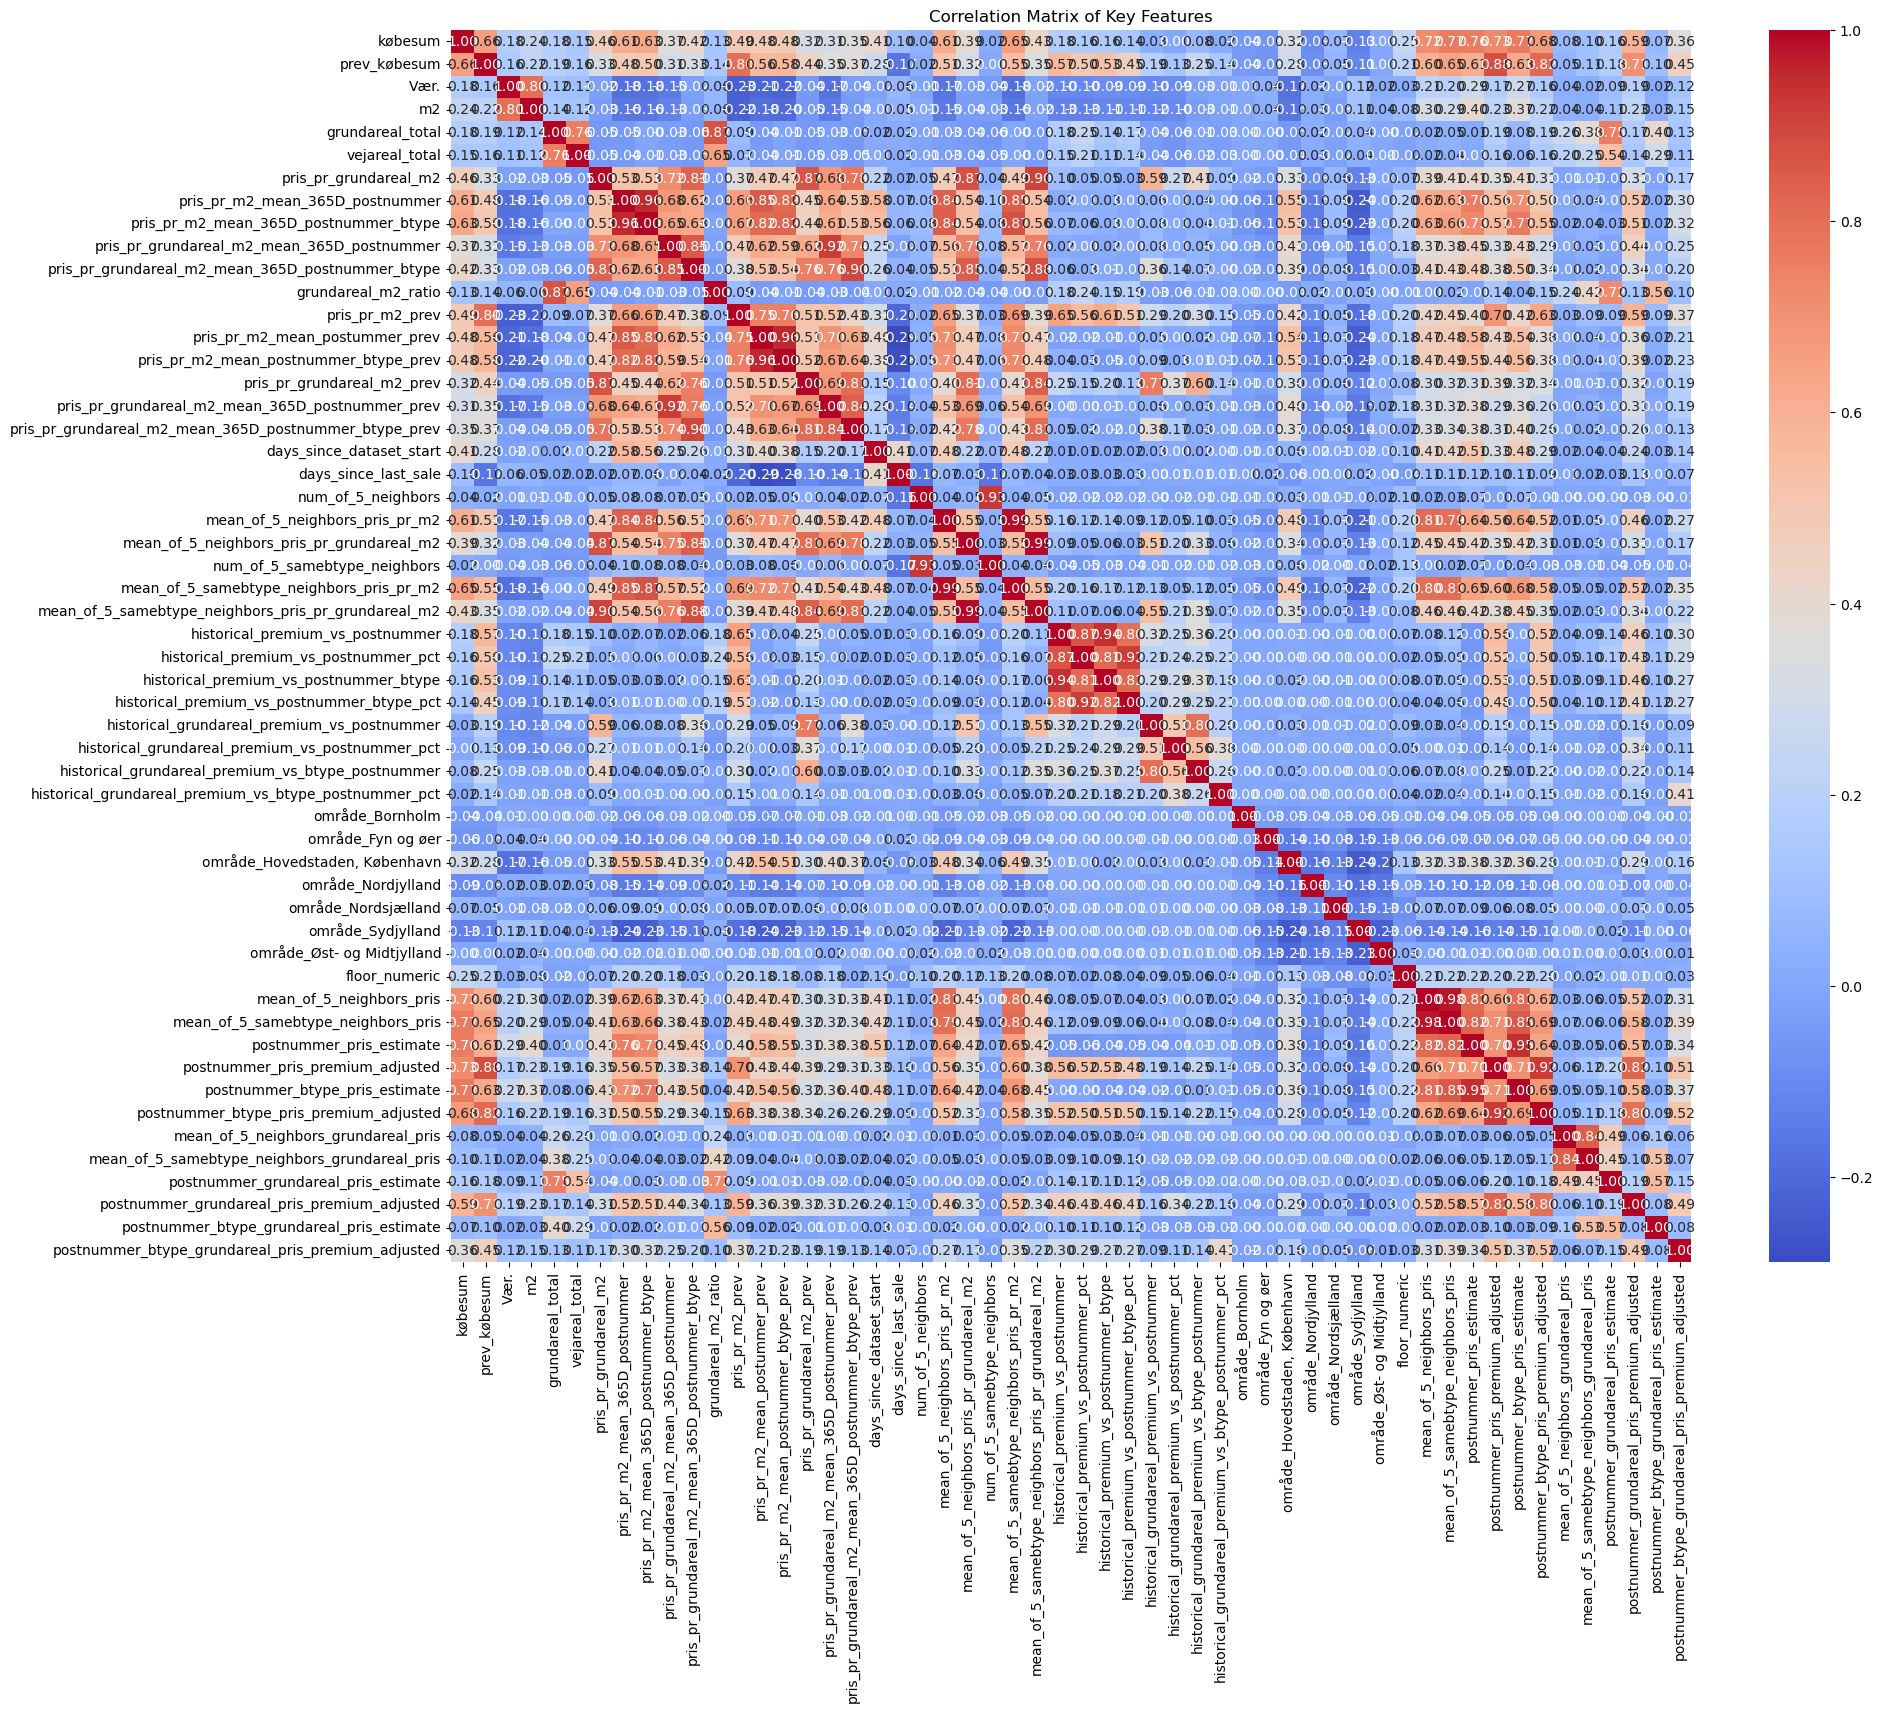

In [107]:
#putting away the bad
correlation_matrix = df.drop(columns=['dato','btype', 'x', 'y', 'index', 'by','postnummer']).corr()
#correlation_matrix = df.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Key Features')
plt.show()

# honestly i could remove more features but i am going to wait to see what you say

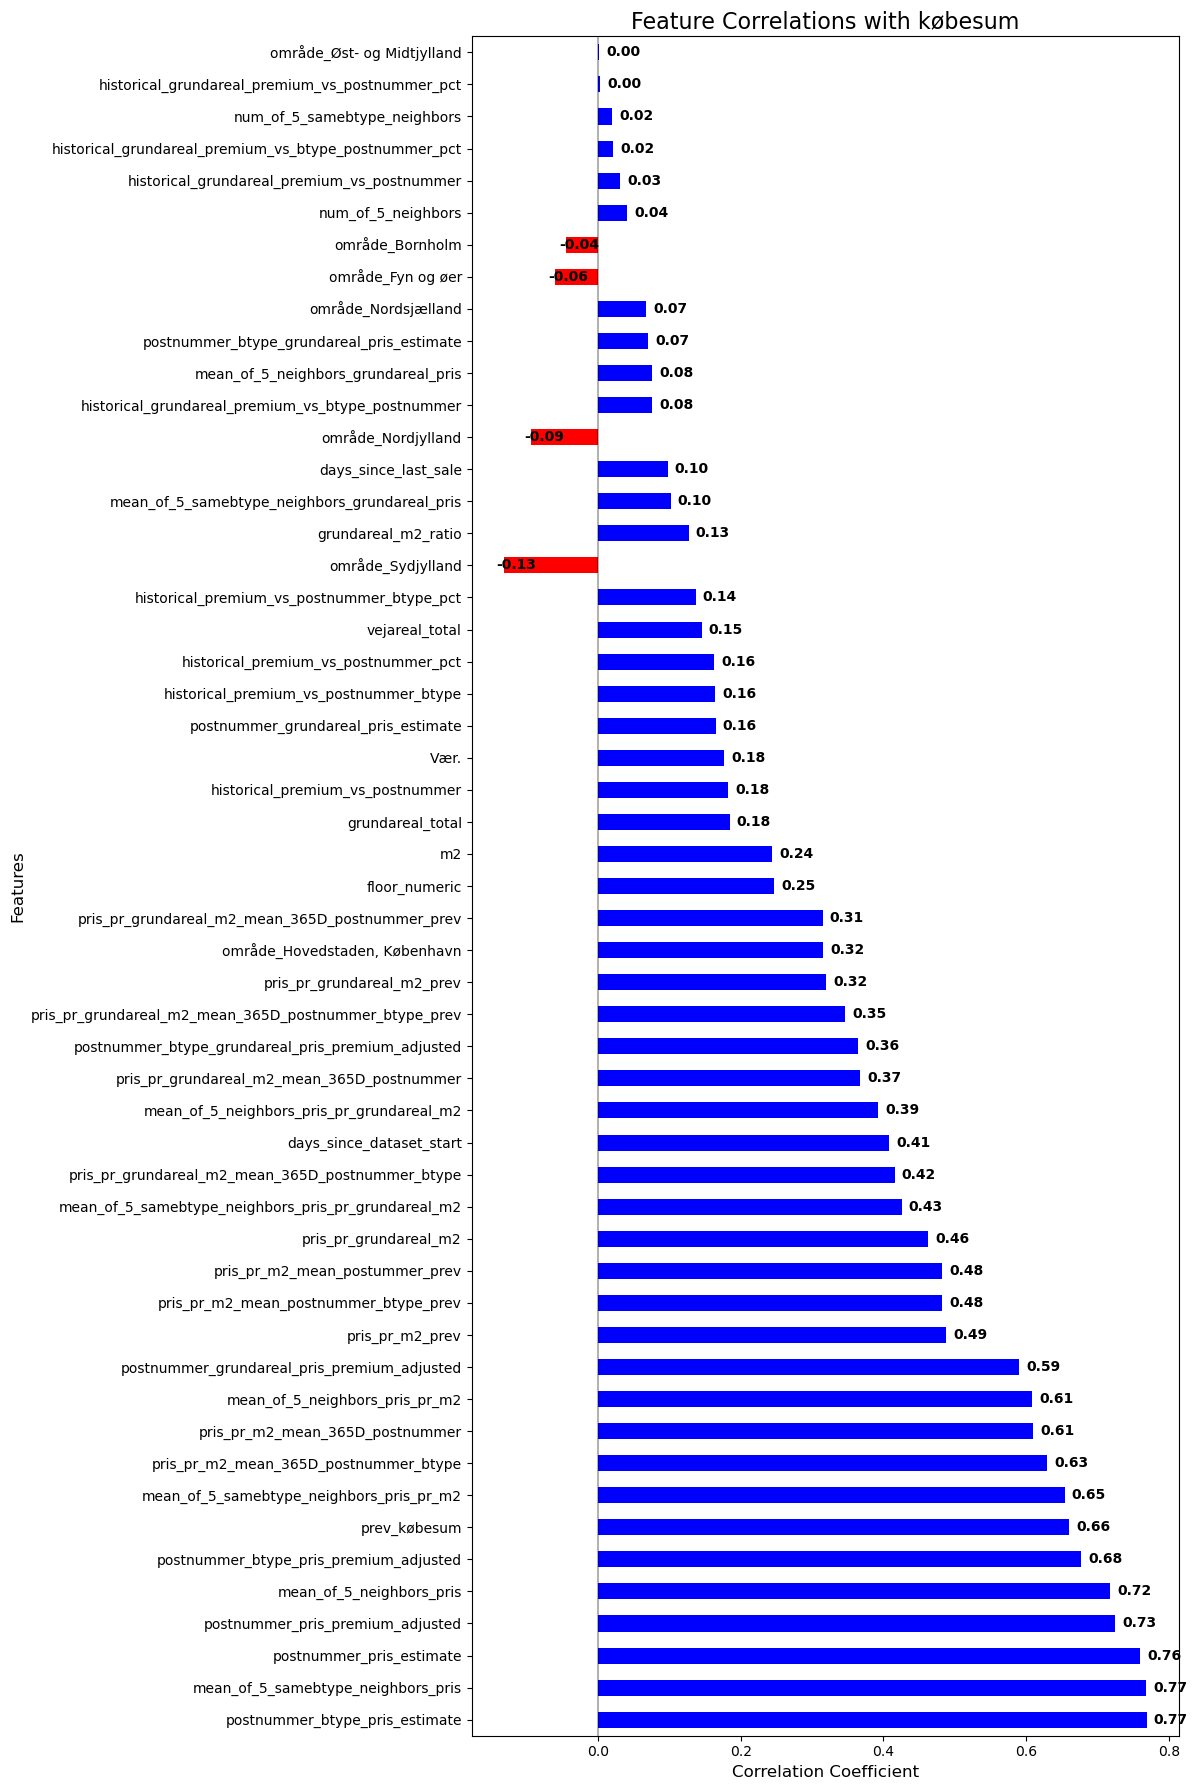

Top 10 features most correlated with købesum:
postnummer_btype_pris_estimate              0.768838
mean_of_5_samebtype_neighbors_pris          0.768475
postnummer_pris_estimate                    0.760085
postnummer_pris_premium_adjusted            0.725133
mean_of_5_neighbors_pris                    0.718073
postnummer_btype_pris_premium_adjusted      0.677439
prev_købesum                                0.660317
mean_of_5_samebtype_neighbors_pris_pr_m2    0.654020
pris_pr_m2_mean_365D_postnummer_btype       0.629215
pris_pr_m2_mean_365D_postnummer             0.609280
dtype: float64


In [108]:
# Calculate correlations with købesum only
df_numeric = df.drop(columns=['dato','btype', 'x', 'y', 'index', 'by','postnummer'])
correlations = df_numeric.corrwith(df_numeric['købesum']).sort_values(ascending=False)

# Remove købesum itself from the results (correlation = 1.0)
correlations = correlations.drop('købesum')

# Sort by absolute value to see strongest correlations (positive or negative)
correlations_abs = correlations.abs().sort_values(ascending=False)
correlations = correlations[correlations_abs.index]

# Plot horizontal bar chart
plt.figure(figsize=(12, 18))
ax = correlations.plot(kind='barh', color=correlations.map(lambda x: 'blue' if x > 0 else 'red'))
plt.title('Feature Correlations with købesum', fontsize=16)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)

# Add correlation values as labels
for i, v in enumerate(correlations):
    ax.text(v + (0.01 if v >= 0 else -0.01), 
            i, 
            f'{v:.2f}', 
            color='black', 
            va='center', 
            fontweight='bold')

plt.tight_layout()
plt.show()

# Optional: Print the top 10 most correlated features
print("Top 10 features most correlated with købesum:")
print(correlations.head(10))

overall mape: 47.6%

By building type:
        btype      mape   count
Ejerlejlighed 23.728941  408046
     Rækkehus 32.444987  172646
        Villa 52.251909 1323849
   Fritidshus 63.319021  280850
  Landejendom 88.820516   43589


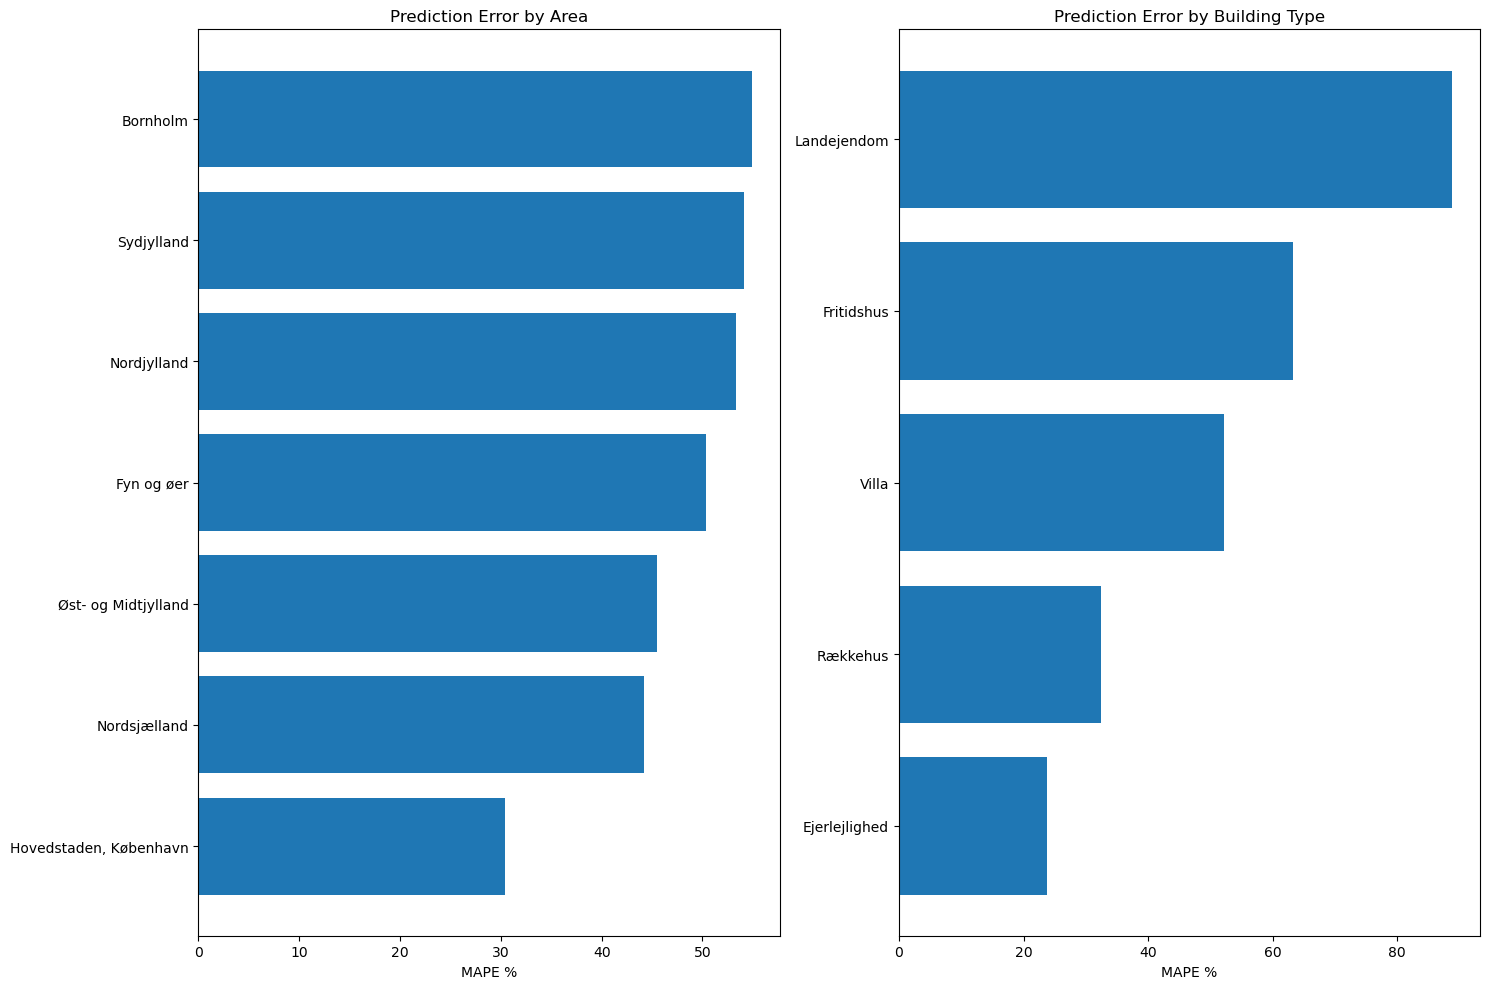


By area:
                  area      mape  count
Hovedstaden, København 30.448235 356520
          Nordsjælland 44.159032 162308
   Øst- og Midtjylland 45.513345 364972
            Fyn og øer 50.315531 187644
           Nordjylland 53.295040 252283
            Sydjylland 54.165536 489881
              Bornholm 54.900140  25815


In [120]:
# just checking how good the nn times price is by area 
df

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

actual = df['købesum']
pred = df['mean_of_30_samebtype_neighbors_pris']

# clean up the data
clean_data = df.dropna(subset=['købesum', 'mean_of_30_samebtype_neighbors_pris'])

print(f"overall mape: {mape(clean_data['købesum'], clean_data['mean_of_30_samebtype_neighbors_pris']):.1f}%")

# by area
area_cols = [col for col in clean_data.columns if 'område_' in col]

# quick plot by area
results = []
for col in area_cols:
    area_data = clean_data[clean_data[col] == 1]
    area_name = col.replace('område_', '')
    area_mape = mape(area_data['købesum'], area_data['mean_of_30_samebtype_neighbors_pris'])
    results.append([area_name, area_mape, len(area_data)])

results_df = pd.DataFrame(results, columns=['area', 'mape', 'count'])
results_df = results_df.sort_values('mape')

plt.figure(figsize=(15, 10))

# Plot by area
plt.subplot(1, 2, 1)
plt.barh(results_df['area'], results_df['mape'])
plt.xlabel('MAPE %')
plt.title('Prediction Error by Area')

if 'btype' in clean_data.columns:
    btype_results = []
    for btype in clean_data['btype'].unique():
            btype_data = clean_data[clean_data['btype'] == btype]
            btype_mape = mape(btype_data['købesum'], btype_data['mean_of_30_samebtype_neighbors_pris'])
            btype_results.append([btype, btype_mape, len(btype_data)])
    
    btype_results_df = pd.DataFrame(btype_results, columns=['btype', 'mape', 'count'])
    btype_results_df = btype_results_df.sort_values('mape')
    
    # Plot by building type
    plt.subplot(1, 2, 2)
    plt.barh(btype_results_df['btype'], btype_results_df['mape'])
    plt.xlabel('MAPE %')
    plt.title('Prediction Error by Building Type')
    
    print(f"\nBy building type:")
    print(btype_results_df.to_string(index=False))

plt.tight_layout()
plt.show()

print(f"\nBy area:")
print(results_df.to_string(index=False))

In [ ]:
# Cell: Add BFE numbers and coordinates back to cleaned data
# Load the original data with BFE and coordinates
df_original = pd.read_csv("with_neighborstesttesttest.csv")  # This has bfe_nummer, x, y
df_filtered = df_original[
    (df_original['postnummer'] == 2960) & 
    (pd.to_datetime(df_original['dato']) >= '2024-01-01') & 
    (pd.to_datetime(df_original['dato']) <= '2025-08-18')
]
print(f"Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: {len(df_filtered)}")

# Get the current cleaned data
df_cleaned = pd.read_csv("cleaned_data_harshertesttesttest.csv")

print(f"Original data shape: {df_original.shape}")
print(f"Cleaned data shape: {df_cleaned.shape}")

# Check if we have a common identifier to merge on
# Look for index or unique identifiers
if 'Unnamed: 0' in df_cleaned.columns and 'Unnamed: 0' in df_original.columns:
    # Merge on the index column
    df = df_cleaned.merge(
        df_original[['Unnamed: 0', 'bfe_nummer', 'x', 'y', 'by', 'postnummer', 'pris_pr_m2']], 
        on='Unnamed: 0', 
        how='left'
    )
elif df_cleaned.index.name == df_original.index.name:
    # Merge on index if they match
    coords_data = df_original[['bfe_nummer', 'x', 'y', 'by', 'postnummer', 'pris_pr_m2']]
    df_with_bfe_coords = pd.concat([df_cleaned, coords_data], axis=1)
else:
    # Try to match by multiple columns (address + date + price)
    # This is more complex but doable if needed
    print("Need to identify matching method...")
    
    # Show what columns we have to work with
    print(f"Cleaned columns: {list(df_cleaned.columns)[:10]}...")
    print(f"Original columns: {list(df_original.columns)[:10]}...")

print(f"Final data with BFE and coords: {df_with_bfe_coords.shape}")
print(f"BFE numbers recovered: {df_with_bfe_coords['bfe_nummer'].notna().sum()}")
print(f"Coordinates recovered: {df_with_bfe_coords['x'].notna().sum()}")

# Filter for postnummer 2960 and date range
df_filtered = df_with_bfe_coords[
    (df_with_bfe_coords['postnummer'] == 2960) & 
    (pd.to_datetime(df_with_bfe_coords['dato']) >= '2024-01-01') & 
    (pd.to_datetime(df_with_bfe_coords['dato']) <= '2025-08-18')
]

print(f"Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: {len(df_filtered)}")

# Save the enhanced dataset
df_with_bfe_coords.to_csv("cleaned_data_with_bfe_coords.csv", index=False)
print("✅ Saved as 'cleaned_data_with_bfe_coords.csv'")

# Quick verification
df_with_bfe_coords[['købesum', 'bfe_nummer', 'x', 'y', 'm2', 'by', 'postnummer', 'pris_pr_m2']].head()

Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: 8
Original data shape: (2352739, 57)
Cleaned data shape: (2352739, 49)
Final data with BFE and coords: (2352739, 55)
BFE numbers recovered: 2352739
Coordinates recovered: 2352739
Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: 8


KeyboardInterrupt: 

In [9]:
import numpy as np
import pandas as pd

def median_ape(actual, pred):
    return np.median(np.abs((actual - pred) / actual)) * 100

results = []
area_cols = [col for col in df.columns if col.startswith('område_')]

for area_col in area_cols:
    area_data = df[df[area_col] == 1]
    area_name = area_col.replace('område_', '')

    # Only use rows with valid price and features
    valid = area_data.dropna(subset=['købesum', 'm2', 'grundareal_total', 'postnummer_pris_estimate', 'postnummer_grundareal_pris_estimate'])

    # Correlations
    corr_m2 = valid['købesum'].corr(valid['m2'])
    corr_grund = valid['købesum'].corr(valid['grundareal_total'])
    corr_post_m2 = valid['købesum'].corr(valid['postnummer_pris_estimate'])
    corr_post_grund = valid['købesum'].corr(valid['postnummer_grundareal_pris_estimate'])

    # Median APEs
    ape_m2 = median_ape(valid['købesum'], valid['m2'])
    ape_grund = median_ape(valid['købesum'], valid['grundareal_total'])
    ape_post_m2 = median_ape(valid['købesum'], valid['postnummer_pris_estimate'])
    ape_post_grund = median_ape(valid['købesum'], valid['postnummer_grundareal_pris_estimate'])

    results.append([
        area_name, len(valid),
        corr_m2, ape_m2,
        corr_grund, ape_grund,
        corr_post_m2, ape_post_m2,
        corr_post_grund, ape_post_grund
    ])

results_df = pd.DataFrame(results, columns=[
    'Area', 'Count',
    'Corr_m2', 'MedianAPE_m2',
    'Corr_grundareal', 'MedianAPE_grundareal',
    'Corr_postnummer_m2', 'MedianAPE_postnummer_m2',
    'Corr_postnummer_grundareal', 'MedianAPE_postnummer_grundareal'
])

print(results_df)

                     Area   Count   Corr_m2  MedianAPE_m2  Corr_grundareal  \
0                Bornholm   28289  0.292564     99.982481         0.409912   
1              Fyn og øer  204890  0.275706     99.987142         0.253406   
2  Hovedstaden, København  409596  0.463257     99.995272         0.055995   
3             Nordjylland  273364  0.275542     99.985489         0.309035   
4            Nordsjælland  187480  0.429768     99.993105         0.169876   
5              Sydjylland  531261  0.285813     99.985111         0.401200   
6     Øst- og Midtjylland  407113  0.253363     99.989920         0.184931   

   MedianAPE_grundareal  Corr_postnummer_m2  MedianAPE_postnummer_m2  \
0             99.890000            0.462334                39.324522   
1             99.919923            0.581847                31.983161   
2             99.999106            0.862303                20.011667   
3             99.889417            0.542151                34.803359   
4             9

In [7]:
df = pd.read_csv("with_neighborstesttesttest.csv")  # This has bfe_nummer, x, y

df['mean_of_5_samebtype_neighbors_pris'] = df['m2'] * df['mean_of_5_samebtype_neighbors_pris_pr_m2']
df['postnummer_grundareal_m2_pris_estimate'] = df['grundareal_total'] * df['pris_pr_grundareal_m2_mean_365D_postnummer_btype']
df['postnummer_m2_pris_estimate'] = df['m2'] * df['pris_pr_m2_mean_365D_postnummer_btype']



In [27]:
df.head()

,dato,index,bfe_nummer,købesum,sale_sequence,total_sales,is_most_recent,prev_købesum,price_change,price_change_pct,prev_sale_date,years_since_last_sale,Købesum,Vær.,Byggeår,dato_y,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,grundareal_total,vejareal_total,pris_pr_m2,pris_pr_grundareal_m2,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_grundareal_m2_mean_365D_postnummer,pris_pr_grundareal_m2_mean_365D_postnummer_btype,grundareal_m2_ratio,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,pris_pr_grundareal_m2_prev,pris_pr_grundareal_m2_mean_365D_postnummer_prev,pris_pr_grundareal_m2_mean_365D_postnummer_btype_prev,days_since_dataset_start,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,std_of_5_neighbors_pris_pr_m2,mean_of_5_neighbors_pris_pr_grundareal_m2,std_of_5_neighbors_pris_pr_grundareal_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,std_of_5_samebtype_neighbors_pris_pr_m2,mean_of_5_samebtype_neighbors_pris_pr_grundareal_m2,std_of_5_samebtype_neighbors_pris_pr_grundareal_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct,historical_grundareal_premium_vs_postnummer,historical_grundareal_premium_vs_postnummer_pct,historical_grundareal_premium_vs_btype_postnummer,historical_grundareal_premium_vs_btype_postnummer_pct
0,2018-12-02 23:00:00+00:00,1905417,100000,4296181,1,1,True,NaN,NaN,NaN,NaN,NaN,4296181,3,2019,11-12-2017,Alm. Salg,133.0,Ejerlejlighed,"Stadionvej 86, 3. 1",2600,Glostrup,"Hovedstaden, København",Sjælland,"Stadionvej 86, 3. 1, 2600 Glostrup",12.374093,55.667897,0.0,0.0,32302.112782,NaN,24761.443802,25434.196252,8600.086148,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,9832,NaN,5,31652.431326,672.960212,NaN,NaN,5,31652.431326,672.960212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-10-14 22:00:00+00:00,1892746,100030,2048000,1,3,False,NaN,NaN,NaN,NaN,NaN,2198000,3,1929,28-07-2020,Alm. Salg,95.0,Ejerlejlighed,"Kronprinsensgade 55, st.",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 55, st., 6700 Esbjerg",8.446658,55.470418,0.0,0.0,21557.894737,NaN,17365.689256,18652.015356,4149.239861,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,9782,NaN,5,22132.609912,580.458977,NaN,NaN,5,22132.609912,580.458977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-09-12 22:00:00+00:00,1974410,100030,2025000,2,3,False,2048000.0,-23000.0,-1.123047,2018-10-14 22:00:00+00:00,0.911704,2198000,3,1929,28-07-2020,Alm. Salg,95.0,Ejerlejlighed,"Kronprinsensgade 55, st.",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 55, st., 6700 Esbjerg",8.446658,55.470418,0.0,0.0,21315.789474,NaN,17177.814239,18063.425951,4552.924684,NaN,0.0,21557.894737,17365.689256,18652.015356,NaN,4149.239861,NaN,10115,333.0,5,22236.670062,390.322481,NaN,NaN,5,22236.670062,390.322481,NaN,NaN,4192.205481,24.140738,2905.879381,15.579439,NaN,NaN,NaN,NaN
3,2020-09-29 22:00:00+00:00,2077295,100030,2198000,3,3,True,2025000.0,173000.0,8.543210,2019-09-12 22:00:00+00:00,1.048597,2198000,3,1929,28-07-2020,Alm. Salg,95.0,Ejerlejlighed,"Kronprinsensgade 55, st.",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 55, st., 6700 Esbjerg",8.446658,55.470418,0.0,0.0,23136.842105,NaN,16949.507296,17645.644387,4178.143986,NaN,0.0,21315.789474,17177.814239,18063.425951,NaN,4552.924684,NaN,10498,383.0,2,26008.533090,3179.585722,NaN,NaN,2,26008.533090,3179.585722,NaN,NaN,4137.975235,24.089067,3252.363522,18.005242,NaN,NaN,NaN,NaN
4,2018-09-30 22:00:00+00:00,1889182,100031,2798000,1,2,False,NaN,NaN,NaN,NaN,NaN,2998000,4,1929,28-02-2019,Alm. Salg,133.0,Ejerlejlighed,"Kronprinsensgade 59, 1. th",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 59, 1. th, 6700 Esbjerg",8.446777,55.470578,0.0,0.0,21037.593985,NaN,17052.296892,18425.000711,3986.454465,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,9768,NaN,3,22027.663051,524.582542,NaN,NaN,3,22027.663051,524.582542,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [8]:
villas_hovedstaden = df[(df.get('btype', '') == 'Villa') & (df.get('postnummer') < 2400) & (df.get('postnummer') > 1000)]
# Sort by date and keep only the most recent sale per property (bfe_nummer)
villas_hovedstaden = villas_hovedstaden.sort_values('dato')
most_recent_villas = villas_hovedstaden.groupby('bfe_nummer').tail(1)

# Select relevant columns
cols = [
    'grundareal_total',
  'postnummer_grundareal_m2_pris_estimate',
    'postnummer_m2_pris_estimate',
    'm2',
    'areal',  # If you have a column named 'areal'
    'købesum',
    'bfe_nummer',
    'pris_pr_m2',
    'pris_pr_grundareal_m2',
]
# Only keep columns that exist
københavnvillaer = most_recent_villas[[col for col in cols if col in most_recent_villas.columns]]
print(len(københavnvillaer))
print(københavnvillaer.head(20))

3249
         grundareal_total  postnummer_grundareal_m2_pris_estimate  \
2434957             778.0                            7.084021e+05   
2434569             578.0                            9.674912e+05   
2434418             242.0                            4.644887e+05   
2434939             718.0                            1.472520e+06   
2433250             728.0                                     NaN   
2434094             766.0                            1.631679e+06   
2433288             352.0                                     NaN   
2434869             617.0                            1.010344e+06   
2434700             496.0                            1.048822e+06   
2433854             564.0                            1.246798e+06   
2434769             672.0                            1.491138e+06   
2434251             677.0                            1.486430e+06   
2434861             603.0                            1.379161e+06   
2434575             670.0    

In [ ]:
import numpy as np
import pandas as pd

def median_ape(actual, pred):
    return np.median(np.abs((actual - pred) / actual)) * 100

# Use københavnvillaer directly, no area loop needed
valid = københavnvillaer.dropna(subset=[
    'købesum', 'm2', 'grundareal_total', 'pris_pr_m2', 'pris_pr_grundareal_m2',
    'postnummer_grundareal_m2_pris_estimate', 'postnummer_m2_pris_estimate'
])

# Correlations
corr_m2 = valid['købesum'].corr(valid['m2'])
corr_grund = valid['købesum'].corr(valid['grundareal_total'])
corr_post_m2 = valid['købesum'].corr(valid['postnummer_m2_pris_estimate'])
corr_post_grund = valid['købesum'].corr(valid['postnummer_grundareal_m2_pris_estimate'])

# Median APEs
ape_m2 = median_ape(valid['købesum'], valid['m2'])
ape_grund = median_ape(valid['købesum'], valid['grundareal_total'])
ape_post_m2 = median_ape(valid['købesum'], valid['postnummer_m2_pris_estimate'])
ape_post_grund = median_ape(valid['købesum'], valid['postnummer_grundareal_m2_pris_estimate'])

results_df = pd.DataFrame([[
    'Københavnvillaer', len(valid),
    corr_m2, ape_m2,
    corr_grund, ape_grund,
    corr_post_m2, ape_post_m2,
    corr_post_grund, ape_post_grund
]], columns=[
    'Area', 'Count',
    'Corr_m2', 'MedianAPE_m2',
    'Corr_grundareal', 'MedianAPE_grundareal',
    'Corr_postnummer_m2', 'MedianAPE_postnummer_m2',
    'Corr_postnummer_grundareal', 'MedianAPE_postnummer_grundareal'
])

print(results_df)

               Area  Count   Corr_m2  MedianAPE_m2  Corr_grundareal  \
0  Københavnvillaer   3176  0.408998     99.997101         0.194479   

   MedianAPE_grundareal  Corr_postnummer_m2  MedianAPE_postnummer_m2  \
0             99.988414            0.823007                22.227596   

   Corr_postnummer_grundareal  MedianAPE_postnummer_grundareal  
0                    0.690035                        27.736322  


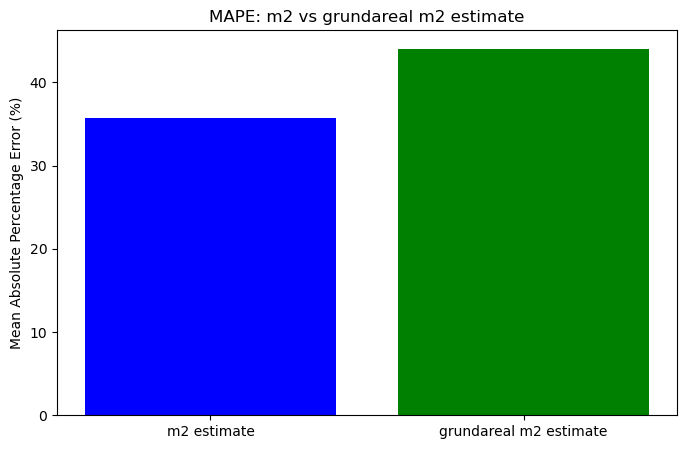

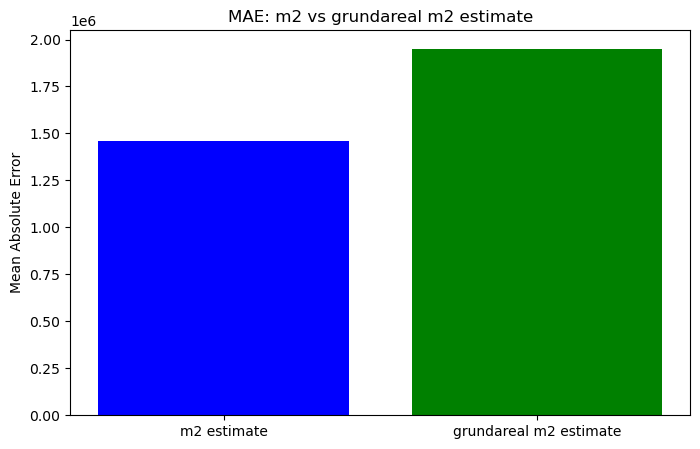

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

def mae(actual, pred):
    return np.mean(np.abs(actual - pred))

# Calculate metrics for m2 estimate
mape_m2 = mape(
    københavnvillaer['købesum'],
    københavnvillaer['postnummer_m2_pris_estimate']
)
mae_m2 = mae(
    københavnvillaer['købesum'],
    københavnvillaer['postnummer_m2_pris_estimate']
)

# Calculate metrics for grundareal m2 estimate
mape_grund = mape(
    københavnvillaer['købesum'],
    københavnvillaer['postnummer_grundareal_m2_pris_estimate']
)
mae_grund = mae(
    københavnvillaer['købesum'],
    københavnvillaer['postnummer_grundareal_m2_pris_estimate']
)

# Plot MAPE
plt.figure(figsize=(8, 5))
plt.bar(['m2 estimate', 'grundareal m2 estimate'], [mape_m2, mape_grund], color=['blue', 'green'])
plt.ylabel('Mean Absolute Percentage Error (%)')
plt.title('MAPE: m2 vs grundareal m2 estimate')
plt.show()

#import matplotlib.pyplot as plt
import numpy as np

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

def mae(actual, pred):
    return np.mean(np.abs(actual - pred))

# Calculate metrics for m2 estimate
mape_m2 = mape(
    københavnvillaer['købesum'],
    københavnvillaer['postnummer_m2_pris_estimate']
)
mae_m2 = mae(
    københavnvillaer['købesum'],
    københavnvillaer['postnummer_m2_pris_estimate']
)

# Calculate metrics for grundareal m2 estimate
mape_grund = mape(
    københavnvillaer['købesum'],
    københavnvillaer['postnummer_grundareal_m2_pris_estimate']
)
mae_grund = mae(
    københavnvillaer['købesum'],
    københavnvillaer['postnummer_grundareal_m2_pris_estimate']
)

# Plot MAPE
plt.figure(figsize=(8, 5))
plt.bar(['m2 estimate', 'grundareal m2 estimate'], [mae_m2, mae_grund], color=['blue', 'green'])
plt.ylabel('Mean Absolute Error')
plt.title('MAE: m2 vs grundareal m2 estimate')
plt.show()
